#### dependencies, paths, dataset download/verification, and imports

In [1]:
# CELL 0


# ============================================================
# Persistent setup (env-var-driven; portable: Colab / vast.ai / local)
# ============================================================
# Handles Python 3.14: installs gfortran (for scipy source build
# fallback) and pins to the newest numpy/scipy which DO ship 3.14
# wheels. Fails loudly on the first broken package -- no silent
# swallowing.
# ============================================================
import os, sys, subprocess, importlib, shutil

import os
os.environ["TORRICC_CKPTS"] = "/workspace/checkpoint_erm_prob"
os.environ["TORRICC_DATA"]  = "/workspace/data"

PY = sys.version_info
print(f"[cfg] Python = {PY.major}.{PY.minor}.{PY.micro}  ({sys.executable})")
if (PY.major, PY.minor) < (3, 9):
    raise SystemExit(f"ABORT: Python {PY.major}.{PY.minor} is too old. Need >=3.9.")

PY314_PLUS = (PY.major, PY.minor) >= (3, 14)
if PY314_PLUS:
    print("[cfg] Python 3.14+ detected. Using recent-only pins + gfortran fallback.")


# -----------------------------------------------------------------
# Install helper -- raises on first broken package
# -----------------------------------------------------------------
def _pip(pkgs, *, index_url=None, extra_args=()):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--prefer-binary"]
    if index_url:
        cmd += ["--index-url", index_url]
    cmd += list(extra_args)
    cmd += list(pkgs)
    print(f"[pip] {' '.join(pkgs)}")
    r = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if r.returncode != 0:
        sys.stderr.write(r.stdout + "\n" + r.stderr + "\n")
        raise RuntimeError(f"pip install failed for: {pkgs}. See error above.")


def _have(pkg):
    try:
        importlib.import_module(pkg)
        return True
    except ImportError:
        return False


def _sh(cmd):
    """Run a shell command, tolerate failure (used for apt-get)."""
    print(f"[sh] {cmd}")
    return subprocess.run(cmd, shell=True, capture_output=True, text=True)


# -----------------------------------------------------------------
# Python 3.14 fallback: install gfortran so that if pip has to build
# scipy from source it at least has the compiler. We do this before
# any pip install that could touch scipy.
# -----------------------------------------------------------------
if PY314_PLUS and shutil.which("gfortran") is None:
    print("[cfg] gfortran not found; attempting apt-get install ...")
    # Try sudo first, fall back to plain apt-get (root shells)
    for prefix in ("sudo ", ""):
        r = _sh(f"{prefix}apt-get update -qq && {prefix}apt-get install -y -qq gfortran build-essential")
        if r.returncode == 0:
            break
    if shutil.which("gfortran") is None:
        print("[warn] could not install gfortran. scipy will likely fail.")
        print("[warn] Best fix: relaunch vast.ai with a Python 3.10-3.13 image.")


# Upgrade pip/setuptools/wheel FIRST -- old pip is the #1 cause of
# "wheel not found, try building from source" failures.
_pip(["pip", "setuptools", "wheel"], extra_args=["--upgrade"])


# -----------------------------------------------------------------
# Numeric core. On 3.14 we force the newest versions (numpy>=2.1,
# scipy>=1.14.1) which DO publish 3.14 wheels; on 3.10-3.13 we keep
# a looser pin.
# -----------------------------------------------------------------
if PY314_PLUS:
    _pip([
        "numpy>=2.1,<3",
        "scipy>=1.14.1",
        "pandas>=2.2",
        "requests>=2.28",
    ])
else:
    _pip([
        "numpy>=1.26,<3",
        "scipy>=1.11,<1.15",
        "pandas>=2.0,<3",
        "requests>=2.28",
    ])


# -----------------------------------------------------------------
# Torch: skip if already installed (vast.ai images ship with it).
# -----------------------------------------------------------------
if _have("torch"):
    import torch as _t
    print(f"[cfg] torch already present: {_t.__version__} (cuda={_t.cuda.is_available()})")
else:
    _pip(["torch", "torchvision", "torchaudio"],
         index_url="https://download.pytorch.org/whl/cu128")


# -----------------------------------------------------------------
# Everything else
# -----------------------------------------------------------------
_pip([
    "timm>=0.9",
    "torchmetrics>=1.0",
    "scikit-learn>=1.3",
    "networkx>=3.0",
    "matplotlib>=3.7",
    "seaborn>=0.12",
    "tabulate>=0.9",
    "pillow>=10.0",
    "tqdm>=4.65",
])

# Geometry/TDA deps are most likely to NOT have 3.14 wheels. We make
# them best-effort so the notebook still loads and the sections that
# don't need them still run.
for geom_pkg in ("gudhi", "ripser", "GraphRicciCurvature"):
    try:
        _pip([geom_pkg])
    except RuntimeError as e:
        print(f"[warn] could not install {geom_pkg}: {e}")
        print(f"[warn] sections that depend on {geom_pkg} will fail.")


# -----------------------------------------------------------------
# Verify imports BEFORE continuing
# -----------------------------------------------------------------
print("\n[verify] importing dependencies ...")
import json, tarfile, pathlib, time, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import requests

from scipy import sparse
from scipy.sparse import csgraph, csr_matrix, spdiags, identity
from scipy.sparse.linalg import eigsh, splu
from scipy.stats import spearmanr
from numpy.linalg import norm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, RandomSampler
import torch.multiprocessing as mp

from torchvision import datasets, transforms, models
from torchvision.transforms import InterpolationMode
import scipy.sparse as sp
from scipy.sparse import csr_matrix, coo_matrix
from scipy.sparse.linalg import eigsh

import timm
from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform

from torchmetrics.classification import MulticlassCalibrationError

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, log_loss
from sklearn.utils import resample, check_random_state
from sklearn.decomposition import PCA
from sklearn.utils import check_random_state
import gudhi as gd



try:
    import gudhi as gd
except ImportError:
    print("[warn] gudhi not available; H0/H1 persistence sections will fail.")
    gd = None
import networkx as nx
try:
    from GraphRicciCurvature.OllivierRicci import OllivierRicci
except ImportError:
    print("[warn] GraphRicciCurvature not available; Ricci sections will fail.")
    OllivierRicci = None

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print(f"[verify] numpy  {np.__version__}")
print(f"[verify] scipy  {__import__('scipy').__version__}")
print(f"[verify] torch  {torch.__version__}  (cuda={torch.cuda.is_available()})")
print(f"[verify] timm   {timm.__version__}")


# ============================================================
# PATHS  --  configure by setting environment variables.
# ============================================================

DATA_DIR  = os.environ.get("TORRICC_DATA",  "./data_ext")
CKPT_ROOT = os.environ.get("TORRICC_CKPTS", "./AnalyticTorsionCheckpoints")

Path(DATA_DIR).mkdir(parents=True,  exist_ok=True)
Path(CKPT_ROOT).mkdir(parents=True, exist_ok=True)

print(f"[cfg] DATA_DIR  = {DATA_DIR}")
print(f"[cfg] CKPT_ROOT = {CKPT_ROOT}")


# ============================================================
# Download helpers (CIFAR-10-C, CIFAR-10.1, CIFAR-10.2)
# ============================================================
def human_size(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} PB"


def download_with_progress(url, dst, chunk_size=1024 * 1024):
    Path(dst).parent.mkdir(parents=True, exist_ok=True)
    temp_dst = dst + ".part"
    resume_bytes = 0
    headers = {}
    if os.path.exists(temp_dst):
        resume_bytes = os.path.getsize(temp_dst)
        headers["Range"] = f"bytes={resume_bytes}-"
    with requests.get(url, stream=True, headers=headers, timeout=60) as r:
        r.raise_for_status()
        total = r.headers.get("Content-Length")
        total = int(total) + resume_bytes if total is not None else None
        bar = tqdm(total=total, initial=resume_bytes, unit="B",
                   unit_scale=True, unit_divisor=1024,
                   desc=f"Downloading {os.path.basename(dst)}", leave=True)
        with open(temp_dst, "ab") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))
        bar.close()
    os.replace(temp_dst, dst)
    print(f"[ok] Downloaded {os.path.basename(dst)} ({human_size(os.path.getsize(dst))})")


def extract_tar_with_progress(tar_path, out_dir):
    print(f"Extracting {os.path.basename(tar_path)} to {out_dir} ...")
    with tarfile.open(tar_path, "r") as tf:
        members = tf.getmembers()
        bar = tqdm(total=len(members), unit="file", desc="Extracting", leave=True)
        for m in members:
            tf.extract(m, out_dir)
            bar.update(1)
        bar.close()
    print("[ok] Extraction complete")


C10C_DIR = os.path.join(DATA_DIR, "CIFAR-10-C")
C101_DIR = os.path.join(DATA_DIR, "CIFAR-10.1")
C102_DIR = os.path.join(DATA_DIR, "CIFAR-10.2")
Path(C101_DIR).mkdir(parents=True, exist_ok=True)
Path(C102_DIR).mkdir(parents=True, exist_ok=True)


def cifar10c_ok(path):
    labels = os.path.join(path, "labels.npy")
    return os.path.exists(labels) and os.path.getsize(labels) > 1000


def c101_ok(path):
    return (os.path.exists(os.path.join(path, "cifar10.1_v6_data.npy")) and
            os.path.exists(os.path.join(path, "cifar10.1_v6_labels.npy")))


def c102_ok(path):
    return (os.path.exists(os.path.join(path, "cifar102_test.npz")) and
            os.path.exists(os.path.join(path, "cifar102_train.npz")))


def dl_small(url, path):
    if not os.path.exists(path):
        download_with_progress(url, path)
    else:
        print(f"Already present: {os.path.basename(path)} ({human_size(os.path.getsize(path))})")


if not cifar10c_ok(C10C_DIR):
    print("CIFAR-10-C not found or incomplete. Downloading (~2.7GB).")
    url = "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1"
    tar_dst = os.path.join(DATA_DIR, "CIFAR-10-C.tar")
    download_with_progress(url, tar_dst)
    extract_tar_with_progress(tar_dst, DATA_DIR)
    try:
        os.remove(tar_dst)
    except FileNotFoundError:
        pass
    if cifar10c_ok(C10C_DIR):
        print("[ok] CIFAR-10-C ready:", C10C_DIR)
    else:
        print("WARNING: CIFAR-10-C seems incomplete. Re-run this cell.")
else:
    print("CIFAR-10-C already present:", C10C_DIR)

if not c101_ok(C101_DIR):
    print("Downloading CIFAR-10.1 v6 files...")
    dl_small("https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v6_data.npy",
             os.path.join(C101_DIR, "cifar10.1_v6_data.npy"))
    dl_small("https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v6_labels.npy",
             os.path.join(C101_DIR, "cifar10.1_v6_labels.npy"))
else:
    print("CIFAR-10.1 already present:", C101_DIR)

if not c102_ok(C102_DIR):
    print("Downloading CIFAR-10.2 NPZ files...")
    dl_small("https://raw.githubusercontent.com/modestyachts/cifar-10.2/master/cifar102_test.npz",
             os.path.join(C102_DIR, "cifar102_test.npz"))
    dl_small("https://raw.githubusercontent.com/modestyachts/cifar-10.2/master/cifar102_train.npz",
             os.path.join(C102_DIR, "cifar102_train.npz"))
else:
    print("CIFAR-10.2 already present:", C102_DIR)

print("[ok] Setup complete. Data root:", DATA_DIR)

[cfg] Python = 3.12.13  (/venv/main/bin/python)
[pip] pip setuptools wheel


[pip] numpy>=1.26,<3 scipy>=1.11,<1.15 pandas>=2.0,<3 requests>=2.28


[cfg] torch already present: 2.11.0+cu128 (cuda=True)
[pip] timm>=0.9 torchmetrics>=1.0 scikit-learn>=1.3 networkx>=3.0 matplotlib>=3.7 seaborn>=0.12 tabulate>=0.9 pillow>=10.0 tqdm>=4.65


[pip] gudhi


[pip] ripser


[pip] GraphRicciCurvature



[verify] importing dependencies ...


[verify] numpy  2.2.6
[verify] scipy  1.13.1
[verify] torch  2.11.0+cu128  (cuda=True)
[verify] timm   1.0.28
[cfg] DATA_DIR  = /workspace/data
[cfg] CKPT_ROOT = /workspace/checkpoint_erm_prob
CIFAR-10-C already present: /workspace/data/CIFAR-10-C
CIFAR-10.1 already present: /workspace/data/CIFAR-10.1
CIFAR-10.2 already present: /workspace/data/CIFAR-10.2
[ok] Setup complete. Data root: /workspace/data


#### Set random seeds and deterministic cuDNN behavior for reproducibility, then select the available compute device (GPU/CPU).

In [2]:
# CELL 1
# Flow: seed value → seed Python/NumPy/PyTorch/CUDA → deterministic cuDNN settings → select device



#Repro results
def seed_all(s=1337):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(1337)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


#### Define train/test preprocessing for CIFAR ERM and ImageNet-style probe experiments, including normalization constants and consistent CIFAR-10 class labels.

In [3]:
# CELL 2
# Flow: raw image → augmentation/resize → tensor → normalization



## CIFAR style Setups / ERM

# CIFAR-10 normalization statistics
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Train augmentations for strong ERM baseline
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Pure test transform (no train-time augs leakage)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])



## ImageNet style Setups / Prob

# ImageNet normalization for the probe
IMNET_MEAN = (0.485, 0.456, 0.406)
IMNET_STD  = (0.229, 0.224, 0.225)

# Transforms for the linear probe (resize to 224 & ImageNet norm)
probe_train_transform = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

probe_test_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])



## Sanity: CIFAR-10 labels are 0...9 consistently across our loaders

CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
label_map = {i:i for i in range(10)}  # kept for clarity


#### Load CIFAR-10 and its OOD variants, with NumPy-backed dataset wrappers and severity-specific access to the 19 CIFAR-10-C corruption types.

In [4]:
# CELL 3
# Flow: NumPy image arrays / torchvision dataset → Dataset wrapper → transform from Cell 2 → (image tensor, label)



## CIFAR DataSet

# Dataset loaders
class CIFAR10Numpy(Dataset):
    def __init__(self, data_np, labels_np, transform):
        self.data = data_np
        self.labels = labels_np.astype(np.int64)
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        img = self.data[i]
        if img.dtype != np.uint8:
            img = (np.clip(img,0,1)*255).astype(np.uint8)
        pil = transforms.functional.to_pil_image(img)
        return self.transform(pil), int(self.labels[i])

# CIFAR-10 train/test
c10_train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
c10_test  = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

# CIFAR-10.1 v6
c101_data = np.load(os.path.join(C101_DIR, "cifar10.1_v6_data.npy"))
c101_labels = np.load(os.path.join(C101_DIR, "cifar10.1_v6_labels.npy"))
c10_1 = CIFAR10Numpy(c101_data, c101_labels, test_transform)

# CIFAR-10.2 (NPZ with keys: images, labels)
c102_npz = np.load(os.path.join(C102_DIR, "cifar102_test.npz"))
c102_images = c102_npz["images"]            # uint8, shape (2000, 32, 32, 3)
c102_labels = c102_npz["labels"].astype(np.int64)
c10_2 = CIFAR10Numpy(c102_images, c102_labels, test_transform)


# CIFAR-10-C (returns severity-specific subsets + 19 corruption types)
class CIFAR10C(Dataset):
    def __init__(self, root, corruption, severity, transform):
        data = np.load(os.path.join(root, corruption + ".npy"))
        labels = np.load(os.path.join(root, "labels.npy"))
        N = data.shape[0]//5
        self.data = data[(severity-1)*N: severity*N]
        self.labels = labels[(severity-1)*N: severity*N]
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        pil = transforms.functional.to_pil_image(self.data[i])
        return self.transform(pil), int(self.labels[i])

C10C_CORRUPTIONS = [
    "brightness","contrast","defocus_blur","elastic_transform","fog","frost",
    "gaussian_blur","gaussian_noise","glass_blur","impulse_noise","jpeg_compression",
    "motion_blur","pixelate","saturate","shot_noise","snow","spatter","speckle_noise","zoom_blur"
]


#### Build probe-compatible CIFAR evaluation datasets using 224px ImageNet-style preprocessing for pretrained feature extractors.

In [5]:
# CELL 4
# Flow: existing CIFAR arrays/datasets → probe_test_transform (resize/crop/ImageNet norm) → probe-ready datasets



# probe-compatible: probe-friendly datasets (224px, ImageNet norm)
try:
    c10_test_probe
except NameError:
    c10_test_probe = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=probe_test_transform)
    c10_1_probe    = CIFAR10Numpy(c101_data,  c101_labels,  probe_test_transform)
    # CIFAR-10.2 was NPZ:
    if 'c102_images' not in globals():
        c102_npz = np.load(os.path.join(C102_DIR, "cifar102_test.npz"))
        c102_images = c102_npz["images"]
        c102_labels = c102_npz["labels"].astype(np.int64)
    c10_2_probe    = CIFAR10Numpy(c102_images, c102_labels, probe_test_transform)


#### Create or reload a fixed class-balanced CIFAR-10 split: 45k samples for training and 5k source-validation samples evaluated with deterministic test preprocessing.

In [6]:
# CELL 5
# Flow: CIFAR-10 train labels → per-class shuffle → 500/class validation + rest training → save/load splits.json → Subset objects


# Save/Load fixed splits
SPLIT_PATH = os.path.join(DATA_DIR, "splits.json")

def make_or_load_splits():
    if os.path.exists(SPLIT_PATH):
        print("Loading saved splits.")
        return json.load(open(SPLIT_PATH, 'r'))
    # stratified 45k train, 5k source-val from CIFAR-10 train
    y = np.array(c10_train.targets)
    idxs = np.arange(len(y))
    val_per_class = 500  # 5k total
    train_sel, val_sel = [], []
    for c in range(10):
        cls_idx = idxs[y==c]
        np.random.shuffle(cls_idx)
        val_sel.extend(cls_idx[:val_per_class])
        train_sel.extend(cls_idx[val_per_class:])
    splits = {"train": list(map(int,train_sel)), "val_src": list(map(int,val_sel))}
    json.dump(splits, open(SPLIT_PATH, 'w'))
    print("Saved splits:", SPLIT_PATH)
    return splits

SPLITS = make_or_load_splits()
train_subset = Subset(c10_train, SPLITS["train"])
val_src_subset = Subset(datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=test_transform),
                        SPLITS["val_src"])


Loading saved splits.


#### Define label-smoothed cross-entropy, a CIFAR-adapted ResNet-18 with optional backbone freezing, and an exponential moving average utility for model parameters.

In [7]:
# CELL 6
# Flow: ImageNet ResNet18 → replace conv1/maxpool/fc → optional backbone freezing → model

## Model builder (32x32) + EMA


# Label Smoothing Cross Entropy
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, logits, target):
        n = logits.size(-1)
        logprobs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logprobs).fill_(self.smoothing / (n - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * logprobs, dim=-1))


# Builds Model / CIFAR adapted ResNet18 
def resnet18_cifar(
    num_classes=10,
    pretrained_imnet=False,
    freeze_backbone_for_probe=False
):
    """
    CIFAR-adapted ResNet-18.

    Main ERM experiments use pretrained_imnet=False so the model is
    genuinely trained from scratch on CIFAR-10.
    """
    weights = (
        models.ResNet18_Weights.IMAGENET1K_V1
        if pretrained_imnet else None
    )

    base = models.resnet18(weights=weights)

    # CIFAR adaptation
    base.conv1 = nn.Conv2d(
        3, 64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )
    base.maxpool = nn.Identity()
    base.fc = nn.Linear(512, num_classes)

    if freeze_backbone_for_probe:
        for name, p in base.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False

    return base


# Keeps a smoothed version of the model parameters
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()
    def update(self, model):
        for name, param in model.named_parameters():
            if name in self.shadow:
                self.shadow[name] = self.decay*self.shadow[name] + (1-self.decay)*param.data
    def apply(self, model):
        self.backup = {}
        for name, param in model.named_parameters():
            if name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])
    def restore(self, model):
        for name, param in model.named_parameters():
            if name in self.backup:
                param.data.copy_(self.backup[name])
        self.backup = {}


#### Define CutMix and Mixup batch augmentations and the corresponding mixed-label training loss.

In [8]:
# CELL 7


# CutMix: Flow: batch → sample λ → random box → patch swap → recompute λ → mixed batch + paired labels


def rand_bbox(W, H, lam):
    cut_ratio = np.sqrt(1. - lam)
    cut_w = int(W * cut_ratio)
    cut_h = int(H * cut_ratio)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2


def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size, C, H, W = x.size()
    index = torch.randperm(batch_size, device=x.device)
    x1,y1,x2,y2 = rand_bbox(W, H, lam)
    new_x = x.clone()
    new_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
    y_a, y_b = y, y[index]
    return new_x, y_a, y_b, lam



# Mixup: Flow: batch → sample λ → shuffle batch → convex image mix → paired labels

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam



# Mixed loss
def mixed_criterion(crit, pred, y_a, y_b, lam):
    return lam * crit(pred, y_a) + (1 - lam) * crit(pred, y_b)


#### Train the CIFAR-10 ERM baseline using SGD, Mixup/CutMix, label smoothing, EMA and optional SWA; evaluate source-validation accuracy/calibration and save checkpoints every 10 epochs for downstream geometry and OOD analysis.

In [9]:
# CELL 8
# Flow: train_subset → DataLoader → ResNet18 → augmentation/mixing → loss → SGD → EMA update → EMA validation → checkpoint saving


# Train ERM strong baseline
def get_loaders(train_ds, val_ds, batch_size=128, workers=0):
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True))


from contextlib import nullcontext

@torch.inference_mode()
def evaluate_clean_ultrafast(
    model,
    loader,
    want_ci=True,
    ci_max_examples=None,
    want_calibration=True,
    use_amp=True
):
    """
    Evaluate full-dataset accuracy.

    Accuracy is ALWAYS computed on every example.
    CI flags may optionally be subsampled after the full evaluation.
    """
    was_training = model.training
    model.eval()

    dev = next(model.parameters()).device

    total_correct = 0
    total_seen = 0

    per_class_correct = torch.zeros(10, device=dev, dtype=torch.long)
    per_class_total   = torch.zeros(10, device=dev, dtype=torch.long)

    all_correct = []
    all_labels_ci = []

    all_probs = []
    all_y = []

    if use_amp and dev.type == "cuda":
        amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16)
    else:
        amp_ctx = nullcontext()

    with amp_ctx:
        for x, y in loader:
            x = x.to(dev, non_blocking=True)
            y = y.to(dev, non_blocking=True)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct = (preds == y)

            total_correct += int(correct.sum().item())
            total_seen += int(y.numel())

            for c in range(10):
                mask = (y == c)
                per_class_total[c] += mask.sum()
                per_class_correct[c] += correct[mask].sum()

            if want_ci:
                all_correct.append(correct.detach().cpu().numpy().astype(np.uint8))
                all_labels_ci.append(y.detach().cpu().numpy())

            if want_calibration:
                probs = torch.softmax(logits.float(), dim=1)
                probs = torch.nan_to_num(
                    probs,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )
                probs = probs / probs.sum(
                    dim=1, keepdim=True
                ).clamp_min(1e-12)

                all_probs.append(probs.cpu())
                all_y.append(y.cpu())

    if was_training:
        model.train()

    # TRUE full-dataset accuracy
    acc = total_correct / max(total_seen, 1)

    per_class = {}
    for c in range(10):
        n = int(per_class_total[c].item())
        per_class[c] = (
            int(per_class_correct[c].item()) / n
            if n > 0 else np.nan
        )

    ci_flags = None
    ci_labels = None

    if want_ci and all_correct:
        ci_flags = np.concatenate(all_correct)
        ci_labels = np.concatenate(all_labels_ci)

        # Optional RANDOM subset for CI only.
        if (
            ci_max_examples is not None
            and len(ci_flags) > ci_max_examples
        ):
            rng = np.random.RandomState(0)
            idx = rng.choice(
                len(ci_flags),
                size=ci_max_examples,
                replace=False
            )
            ci_flags = ci_flags[idx]
            ci_labels = ci_labels[idx]

    ece = np.nan
    nll = np.nan

    if want_calibration and all_probs:
        probs = torch.cat(all_probs)
        y_all = torch.cat(all_y)

        try:
            ece = float(
                MulticlassCalibrationError(
                    num_classes=10,
                    n_bins=15,
                    norm="l1"
                )(probs, y_all)
            )
        except Exception:
            ece = np.nan

        try:
            nll = float(
                log_loss(
                    y_all.numpy(),
                    probs.numpy(),
                    labels=list(range(10))
                )
            )
        except Exception:
            nll = np.nan

    return (
        float(acc),
        per_class,
        ci_flags,
        ci_labels,
        float(ece),
        float(nll)
    )





def acc_with_ci_from_correct(correct_flags, B=200, alpha=0.05, rng=None):
    if correct_flags is None or len(correct_flags)==0:
        return np.nan, np.nan, np.nan
    rng = np.random.RandomState(0) if rng is None else rng
    n = len(correct_flags)
    stats = []
    for _ in range(B):
        idx = rng.randint(0, n, n)
        stats.append(float(correct_flags[idx].mean()))
    lo = np.percentile(stats, 100*alpha/2)
    hi = np.percentile(stats, 100*(1-alpha/2))
    return float(correct_flags.mean()), float(lo), float(hi)


def train_erm(
    epochs=200,
    batch_size=128,
    lr=0.1,
    weight_decay=5e-4,
    mixup_alpha=0.2,
    cutmix_alpha=0.0,
    label_smoothing=0.1,
    use_ema=False,
    ema_decay=0.999,
    use_swa=False,
    swa_start=150,
    ckpt_dir="./checkpoints_erm"
):
    os.makedirs(ckpt_dir, exist_ok=True)

    # IMPORTANT: genuinely from scratch
    model = resnet18_cifar(
        pretrained_imnet=False
    ).to(device)

    opt = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=epochs
    )

    criterion = LabelSmoothingCE(
        smoothing=label_smoothing
    )

    ema = EMA(model, decay=ema_decay) if use_ema else None

    if use_swa:
        swa_model = torch.optim.swa_utils.AveragedModel(model)
        swa_sched = torch.optim.swa_utils.SWALR(
            opt,
            anneal_strategy="cos",
            anneal_epochs=10,
            swa_lr=lr * 0.05
        )

    train_loader, val_loader = get_loaders(
        train_subset,
        val_src_subset,
        batch_size=batch_size
    )

    best_val = -np.inf
    best_path = None

    for ep in range(epochs):

        model.train()
        epoch_loss = 0.0

        for x, y in tqdm(
            train_loader,
            desc=f"Train E{ep}",
            leave=False
        ):
            x = x.to(device)
            y = y.to(device)

            r = random.random()

            if cutmix_alpha > 0 and r < 0.5:
                x_m, y_a, y_b, lam = cutmix_data(
                    x, y,
                    alpha=cutmix_alpha
                )
                logits = model(x_m)
                loss = mixed_criterion(
                    criterion,
                    logits,
                    y_a,
                    y_b,
                    lam
                )

            elif mixup_alpha > 0:
                x_m, y_a, y_b, lam = mixup_data(
                    x, y,
                    alpha=mixup_alpha
                )
                logits = model(x_m)
                loss = mixed_criterion(
                    criterion,
                    logits,
                    y_a,
                    y_b,
                    lam
                )

            else:
                logits = model(x)
                loss = criterion(logits, y)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            if ema is not None:
                ema.update(model)

            epoch_loss += loss.item()

        if use_swa and ep >= swa_start:
            swa_model.update_parameters(model)
            swa_sched.step()
        else:
            sched.step()

        # -------------------------------------------------
        # Evaluate exactly the state that will be saved.
        # -------------------------------------------------

        if ema is not None:
            ema.apply(model)

        val_acc, _, _, _, ece, nll = evaluate_clean(
            model,
            val_loader
        )

        # Copy evaluated state BEFORE EMA restore
        state_to_save = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        if ema is not None:
            ema.restore(model)

        if val_acc > best_val:
            best_val = val_acc
            best_path = os.path.join(
                ckpt_dir,
                "best.pt"
            )

            torch.save(
                {
                    "model": state_to_save,
                    "epoch": ep,
                    "use_ema": use_ema
                },
                best_path
            )

        if ep % 10 == 0 or ep == epochs - 1:
            pth = os.path.join(
                ckpt_dir,
                f"ep{ep:03d}.pt"
            )

            torch.save(
                {
                    "model": state_to_save,
                    "epoch": ep,
                    "use_ema": use_ema
                },
                pth
            )

        print(
            f"Epoch {ep}: "
            f"train_loss {epoch_loss / len(train_loader):.4f}  "
            f"val_acc {val_acc:.4f}  "
            f"ECE {ece:.4f}  "
            f"NLL {nll:.4f}"
        )

    if use_swa:
        torch.optim.swa_utils.update_bn(
            train_loader,
            swa_model,
            device=device
        )

        torch.save(
            {
                "model": swa_model.module.state_dict(),
                "epoch": epochs
            },
            os.path.join(ckpt_dir, "swa_final.pt")
        )

    print("Best val_acc:", best_val, "->", best_path)

    return best_path, ckpt_dir


# Compatibility wrapper for train_erm()
@torch.inference_mode()
def evaluate_clean(model, loader):
    was_training = model.training
    model.eval()

    all_probs, all_y = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        probs_t = torch.softmax(logits.float(), dim=1)

        # sanitize numerics
        probs_t = torch.nan_to_num(probs_t, nan=0.0, posinf=0.0, neginf=0.0)
        row_sums = probs_t.sum(dim=1, keepdim=True).clamp_min(1e-12)
        probs_t = probs_t / row_sums

        all_probs.append(probs_t.cpu())
        all_y.append(y.cpu())

    if was_training:
        model.train()

    probs = torch.cat(all_probs).numpy()
    y_np  = torch.cat(all_y).numpy()
    preds = probs.argmax(1)
    acc = float((preds == y_np).mean())

    # per-class accuracy
    per_class = {}
    for c in range(10):
        m = (y_np == c)
        per_class[c] = float((preds[m] == y_np[m]).mean()) if m.any() else float('nan')

    # ECE/NLL with defensive guards
    try:

        ece_metric = MulticlassCalibrationError(num_classes=10, n_bins=15, norm='l1')
        ece = float(ece_metric(torch.tensor(probs), torch.tensor(y_np)))
    except Exception:
        ece = float('nan')

    try:

        nll = float(log_loss(y_np, probs, labels=list(range(10))))
    except Exception:
        nll = float('nan')

    return acc, per_class, probs, y_np, ece, nll


#### Train a linear CIFAR-10 classifier on an ImageNet-pretrained ResNet-18 backbone using ImageNet-style preprocessing, while freezing backbone parameters and selecting the best source-validation checkpoint.

In [10]:
# CELL 9
# Flow: CIFAR images → ImageNet-style transform → frozen pretrained ResNet18 backbone → trainable FC layer → validation metrics


# Linear probe on *true* ImageNet features
def resnet18_imagenet_backbone(num_classes=10):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # keep conv1/maxpool as-is; this preserves genuine ImageNet features
    m.fc = nn.Linear(512, num_classes)
    return m

def get_probe_loaders(batch_size=256, workers=0):
    c10_train_probe = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=probe_train_transform)
    c10_val_probe   = datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=probe_test_transform)
    train_probe_subset = Subset(c10_train_probe, SPLITS["train"])
    val_probe_subset   = Subset(c10_val_probe,   SPLITS["val_src"])
    return (
        DataLoader(train_probe_subset, batch_size=batch_size, shuffle=True,  num_workers=workers, pin_memory=True),
        DataLoader(val_probe_subset,   batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True),
    )

def train_linear_probe(epochs=30, batch_size=256, lr=0.2, wd=1e-4, ckpt_dir="./checkpoints_probe"):
    os.makedirs(ckpt_dir, exist_ok=True)
    model = resnet18_imagenet_backbone(num_classes=10).to(device)
    # freeze all but the final FC
    for n, p in model.named_parameters():
        if not n.startswith("fc."):
            p.requires_grad = False

    opt = torch.optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_loader, val_loader = get_probe_loaders(batch_size=batch_size)

    best_val, best_path = 0.0, None
    for ep in range(epochs):
        # Keep the pretrained backbone, including BatchNorm statistics, frozen.
        model.eval()
        model.fc.train()
        run_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Probe E{ep}", leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()
            run_loss += loss.item()
        sched.step()

        # eval (standard eval; no BN trickery)
        was_train = model.training
        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                all_logits.append(model(x).cpu()); all_y.append(y.cpu())
        if was_train: model.train()
        logits = torch.cat(all_logits); y_np = torch.cat(all_y).numpy()
        probs = torch.softmax(logits, dim=1).numpy()
        preds = logits.argmax(1).numpy()
        val_acc = (preds == y_np).mean()
        ece = float(MulticlassCalibrationError(num_classes=10, n_bins=15, norm='l1')(
            torch.tensor(probs), torch.tensor(y_np)))
        nll = float(log_loss(y_np, probs, labels=list(range(10))))

        if val_acc > best_val:
            best_val = val_acc
            best_path = os.path.join(ckpt_dir, "best.pt")
            torch.save({"model": model.state_dict(), "epoch": ep}, best_path)

        print(f"[Probe] Epoch {ep}: loss {run_loss/len(train_loader):.4f}  val_acc {val_acc:.4f}  ECE {ece:.4f}  NLL {nll:.4f}")

    print("Best probe val_acc:", best_val)
    return best_path, ckpt_dir


#### Load ERM or linear-probe checkpoints and evaluate ID/OOD performance across CIFAR-10, CIFAR-10.1/10.2, and CIFAR-10-C, reporting accuracy, confidence intervals, calibration error, and NLL.

In [11]:
# CELL 10
# Flow: checkpoint → rebuild architecture → load weights → dataset loader → logits → accuracy/calibration/CI → results DataFrame
# For CIFAR-10-C: severity → corruption datasets → evaluation per corruption → aggregate → severity/overall results      

def acc_with_ci_from_probs(probs, y):
    correct = (np.asarray(probs).argmax(1) == np.asarray(y)).astype(np.uint8)
    return acc_with_ci_from_correct(correct, B=1000)


# Two model loaders
def load_model_erm(path):
    # Architecture only; state_dict provides all learned weights.
    m = resnet18_cifar(
        pretrained_imnet=False
    ).to(device)

    sd = torch.load(
        path,
        map_location=device
    )["model"]

    m.load_state_dict(sd, strict=True)
    return m


def load_model_probe(path):
    m = resnet18_imagenet_backbone(
        num_classes=10
    ).to(device)

    sd = torch.load(
        path,
        map_location=device
    )["model"]

    m.load_state_dict(sd, strict=True)
    return m


def load_model(path, arch="erm"):
    if arch == "erm":
        return load_model_erm(path)

    if arch == "probe":
        return load_model_probe(path)

    raise ValueError(
        "arch must be 'erm' or 'probe'"
    )

def make_loader(ds, bs=512, workers=None):
    if workers is None:
        workers = max(
            2,
            (os.cpu_count() or 2) // 2
        )

    return DataLoader(
        ds,
        batch_size=bs,
        shuffle=False,
        num_workers=workers,
        pin_memory=True
    )



@torch.inference_mode()
def collect_logits_and_labels(model, loader, use_amp=True):
    """
    Collect logits and labels for calibration metrics (ECE/NLL).
    Intended for CIFAR-10-C aggregation.
    """
    model_was_training = model.training
    model.eval()

    all_logits = []
    all_labels = []

    amp_ctx = torch.cuda.amp.autocast if (use_amp and torch.cuda.is_available()) else torch.cpu.amp.autocast
    with amp_ctx():
        for x, y in loader:
            x = x.to(next(model.parameters()).device, non_blocking=True)
            y = y.to(x.device, non_blocking=True)

            logits = model(x)
            all_logits.append(logits.detach().cpu())
            all_labels.append(y.detach().cpu())

    if model_was_training:
        model.train()

    return torch.cat(all_logits), torch.cat(all_labels)





def eval_suite(ckpt_path, arch='erm', fast=False, c10c_max_corr=19, c10c_severities=(1,2,3,4,5),
               include_ci=True, ci_examples=1500, include_calibration=True,
               only_datasets=("c10","c101","c102","c10c")):

    if arch == 'erm':
        model = load_model_erm(ckpt_path)
        ds_map = {
            "c10":  (c10_test,        test_transform),
            "c101": (c10_1,           test_transform),
            "c102": (c10_2,           test_transform),
        }
        tform_c = test_transform
        bs_default = 1024

    elif arch == 'probe':
        model = load_model_probe(ckpt_path)
        ds_map = {
            "c10":  (c10_test_probe,  probe_test_transform),
            "c101": (c10_1_probe,     probe_test_transform),
            "c102": (c10_2_probe,     probe_test_transform),
        }
        tform_c = probe_test_transform
        bs_default = 1024

    else:
        raise ValueError("arch must be 'erm' or 'probe'.")

    results = []

    # ----------------------------
    # Standard datasets
    # ----------------------------
    def run_one(name, dataset_obj):
        loader = make_loader(dataset_obj, bs=bs_default)
        acc, pc, ci_flags, ci_labels, ece, nll = evaluate_clean_ultrafast(
            model, loader,
            want_ci=include_ci, ci_max_examples=ci_examples,
            want_calibration=include_calibration, use_amp=True
        )
        # Point estimate ALWAYS uses the complete dataset.
        a = acc

        if include_ci:
            _, lo, hi = acc_with_ci_from_correct(
                ci_flags,
                B=1000)
        else:
            lo, hi = np.nan, np.nan

        results.append([name, float(a), float(lo), float(hi),
                        float(ece) if ece is not None else np.nan,
                        float(nll) if nll is not None else np.nan])

    if "c10"  in only_datasets: run_one("CIFAR-10 (test)", ds_map["c10"][0])
    if "c101" in only_datasets: run_one("CIFAR-10.1 v6",   ds_map["c101"][0])
    if "c102" in only_datasets: run_one("CIFAR-10.2",      ds_map["c102"][0])

    # ----------------------------
    # CIFAR-10-C (FIXED)
    # ---------------------------

    if "c10c" in only_datasets:
        corrs = (C10C_CORRUPTIONS[:c10c_max_corr] if fast else C10C_CORRUPTIONS)
        severities = list(c10c_severities) if c10c_severities is not None else [1,2,3,4,5]

        sev_means = {}

        for sev in severities:
            all_logits = []
            all_labels = []
            all_ci_flags = []
            corr_accs = []
            for corr in corrs:
                ds = CIFAR10C(C10C_DIR, corr, sev, tform_c)
                loader = make_loader(ds, bs=bs_default)

                # fast accuracy + CI flags
                acc, _, ci_flags, _, _, _ = evaluate_clean_ultrafast(
                    model, loader,
                    want_ci=include_ci,
                    ci_max_examples=ci_examples,
                    want_calibration=False,   # IMPORTANT
                    use_amp=True
                )

                # slow but correct: collect logits for calibration
                if include_calibration:
                    logits, labels = collect_logits_and_labels(model, loader)
                    all_logits.append(logits)
                    all_labels.append(labels)

                if include_ci and ci_flags is not None:
                    all_ci_flags.append(ci_flags)
                corr_accs.append(float(acc))
                
            # Aggregate
            if include_calibration:
                logits = torch.cat(all_logits)
                labels = torch.cat(all_labels)
                ece = float(MulticlassCalibrationError(
                    num_classes=10, n_bins=15, norm='l1'
                )(logits.softmax(1), labels))
                nll = float(log_loss(labels.numpy(), logits.softmax(1).numpy(),
                                     labels=list(range(10))))
            else:
                ece, nll = np.nan, np.nan

                
            a = float(np.mean(corr_accs))
            if include_ci and len(all_ci_flags):
                pooled_flags = np.concatenate(all_ci_flags)
                _, lo, hi = acc_with_ci_from_correct(
                    pooled_flags,
                    B=1000)
            else:
                lo, hi = np.nan, np.nan

            sev_means[sev] = a

            results.append([
                f"CIFAR-10-C (sev={sev}, mean over {len(corrs)})",
                float(a), float(lo), float(hi), float(ece), float(nll)
            ])

        results.append([
            f"CIFAR-10-C (overall mean {len(corrs)}×{len(severities)})",
            float(np.mean(list(sev_means.values()))),
            np.nan, np.nan, np.nan, np.nan
        ])


    return pd.DataFrame(results, columns=["Dataset","Acc","CI_lo","CI_hi","ECE","NLL"])




#### Extract class-labeled intermediate representations from model checkpoints using forward hooks at avgpool or layer4, flatten them into point-cloud vectors, and optionally apply row-wise L2 normalization for geometric analysis.

In [12]:
# CELL 11
# Flow: checkpoint → load model → hook avgpool/layer4 → forward pass → captured features → flatten → concatenate → L2 normalize → (X, y)


# yielding a well-defined point cloud on which geometric and topological invariants such as curvature and analytic torsion can be computed.

# Embedding extractor (avgpool or pre-classifier)
def get_feature_hook(layer_name="avgpool"):
    feats = {}
    def hook(module, inp, out):
        feats["x"] = out.detach()
    return feats, hook

#  make preclassifier embeddings 2D
# CELL 11
# Flow: checkpoint → ResNet-18 avgpool output → flatten → L2 normalize → penultimate embeddings (X, y)

def extract_embeddings(
    ckpt_path,
    loader,
    layer="penultimate",
    l2_norm=True,
    arch="erm"
):
    model = load_model(ckpt_path, arch=arch)
    model.eval()

    captured = {}

    def hook(module, inputs, output):
        captured["x"] = output.detach()

    # ResNet-18: layer4 → avgpool → flatten → fc
    # Therefore, avgpool output is the penultimate representation.
    if layer not in {"penultimate", "avgpool", "preclassifier"}:
        raise ValueError(
            "layer must be 'penultimate', 'avgpool', or 'preclassifier'"
        )

    handle = model.avgpool.register_forward_hook(hook)

    embs, labels = [], []

    try:
        with torch.inference_mode():
            for x, y in loader:
                x = x.to(device, non_blocking=True)
                _ = model(x)

                # avgpool: (batch, 512, 1, 1) → (batch, 512)
                z = torch.flatten(captured["x"], start_dim=1)

                embs.append(z.cpu())
                labels.append(y.cpu())
    finally:
        handle.remove()

    X = torch.cat(embs, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()

    if l2_norm:
        X = X / (
            np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        )

    return X.astype(np.float64), y.astype(np.int64)

#### Provide embedding preprocessing utilities for row-wise L2 normalization or PCA whitening, returning both the transformed representation and the fitted PCA model when applicable.

In [13]:
# CELL 12
# Flow: X → preprocess_embeddings() → "l2": X → l2_normalize(X) → "pca_whiten": X → PCA.fit_transform(X)


#  Embedding preprocessing (L2 or PCA-whiten)

def l2_normalize(X):
    X = np.asarray(X, dtype=np.float64)

    nrm = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )

    return X / np.maximum(nrm, 1e-12)


def pca_whiten_l2(
    X,
    n_comp=None,
    random_state=0
):
    """
    PCA whitening followed by L2 normalization.

    This ensures graph construction always receives normalized vectors.
    """
    X = np.asarray(X, dtype=np.float64)

    max_comp = min(
        X.shape[0],
        X.shape[1]
    )

    if n_comp is None:
        n_comp = max_comp
    else:
        n_comp = min(
            n_comp,
            max_comp
        )

    pca = PCA(
        n_components=n_comp,
        whiten=True,
        random_state=random_state
    )

    Xw = pca.fit_transform(X)

    return l2_normalize(Xw), pca


def preprocess_embeddings(
    X,
    mode="l2",
    pca_dim=None,
    random_state=0
):
    if mode == "l2":
        return l2_normalize(X), None

    if mode == "pca_whiten":
        return pca_whiten_l2(
            X,
            n_comp=pca_dim,
            random_state=random_state
        )

    raise ValueError(
        "mode must be 'l2' or 'pca_whiten'"
    )


#### Compare L2-normalized and PCA-whitened embedding representations by computing graph, spectral, and topological diagnostics under each preprocessing mode.

In [14]:
# CELL 13
# Flow: checkpoint → raw embeddings → preprocess (L2 or PCA-whiten) → class-balanced sample → mutual kNN graph → normalized Laplacian → topology metrics + torsion → comparison DataFrame


#  Normalisation comparison: L2 vs PCA-whiten

def compare_normalizations(
    ckpt_path,
    loader,
    layer="avgpool",
    k=10,
    per_class=100,
    pca_dim=256,
    arch="erm"
):
    """
    Compare L2 normalization against PCA-whitening + L2 normalization.
    """

    X, y = extract_embeddings(
        ckpt_path,
        loader,
        layer=layer,
        l2_norm=False,
        arch=arch
    )

    results = {}

    X_l2, _ = preprocess_embeddings(
        X,
        mode="l2"
    )

    results["l2"] = topology_metrics_from_embeddings(
        X_l2,
        y,
        k=k,
        per_class=per_class
    )

    X_pca, _ = preprocess_embeddings(
        X,
        mode="pca_whiten",
        pca_dim=pca_dim
    )

    results["pca_whiten"] = topology_metrics_from_embeddings(
        X_pca,
        y,
        k=k,
        per_class=per_class
    )

    return pd.DataFrame(results).T




#### Construct L2-normalized self-tuning weighted mutual kNN graphs and provide Laplacian-based spectral diagnostics, including log-determinant, spectral entropy, algebraic connectivity, and multiscale heat traces.

In [15]:
# CELL 14
# Flow: X → internal L2 norm → kNN → self-tuning weights → mutual graph W → Laplacian → spectral metrics



#
# Weighted mutual kNN + self-tuning kernel + spectral utilities
#

import numpy as np
import scipy.sparse as sp
from numpy.linalg import norm
from scipy import sparse
from scipy.sparse import identity, spdiags, csgraph
from scipy.sparse.linalg import splu, eigsh
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA


#
# Weighted mutual kNN with self-tuning kernel
#
def build_weighted_mutual_knn(X, k=10, metric='euclidean', eps=1e-12):
    """
    Weighted mutual kNN with self-tuning kernel:
        w_ij = exp(- ||xi - xj||^2 / (sigma_i * sigma_j)),

    where sigma_i is the distance to the k-th neighbor of xi.

    Notes:
    - X is L2-normalized internally before graph construction.
    - Returns a symmetric CSR matrix W (weights).
    """
    # Internal L2 normalization (single source of truth)
    X = X / (norm(X, axis=1, keepdims=True) + eps)

    nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(X)
    dists, idxs = nbrs.kneighbors(X)
    n = X.shape[0]

    sigmas = dists[:, -1].copy()
    sigmas[sigmas < eps] = eps

    rows, cols, vals = [], [], []
    for i in range(n):
        neigh = idxs[i, 1:]
        d2 = dists[i, 1:] ** 2
        s_i = sigmas[i]
        s_j = sigmas[neigh]
        w = np.exp(-d2 / (s_i * s_j + eps))
        rows.extend([i] * len(neigh))
        cols.extend(neigh.tolist())
        vals.extend(w.tolist())

    W_dir = sparse.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()

    # Mutual kNN
    W = W_dir.minimum(W_dir.T).tocsr()
    W.eliminate_zeros()
    return W






def full_psd_spectrum(L, tol=1e-10):
    """
    Full eigenvalue spectrum of a small symmetric PSD Laplacian.

    Class-conditional graphs contain ~100 vertices, so dense eigendecomposition
    is both exact and cheap.
    """
    A = L.toarray() if sp.issparse(L) else np.asarray(L)

    A = 0.5 * (A + A.T)

    vals = np.linalg.eigvalsh(A)

    vals[np.abs(vals) < tol] = 0.0

    return np.clip(vals, 0.0, None)




#
# Laplacians
#
def normalized_laplacian(W, eps=1e-12):
    """
    Symmetric normalized Laplacian.

    Isolated vertices receive zero diagonal, matching the standard
    normalized-Laplacian convention.
    """
    W = W.tocsr().astype(np.float64)

    d = np.asarray(
        W.sum(axis=1)
    ).ravel()

    inv_sqrt = np.zeros_like(d)

    valid = d > eps
    inv_sqrt[valid] = 1.0 / np.sqrt(d[valid])

    D_inv_sqrt = sparse.diags(inv_sqrt)

    L = -D_inv_sqrt @ W @ D_inv_sqrt

    diag = np.zeros_like(d)
    diag[valid] = 1.0
    L.setdiag(diag)

    return L.tocsr()


def combinatorial_laplacian(W):
    d = np.asarray(W.sum(axis=1)).ravel()
    return sparse.diags(d) - W


#
# Reduced log-determinants (Kirchhoff-style)
#
def reduced_logdet_combinatorial(L):
    """
    Reduced log-determinant of the combinatorial Laplacian.
    Computed per connected component via sparse LU.
    """
    # Convert Laplacian -> adjacency for connectivity
    A = (-L).tocsr()
    A.setdiag(0)
    A.eliminate_zeros()

    ncomp, labels = csgraph.connected_components(A, directed=False)

    total = 0.0
    for c in range(ncomp):
        nodes = np.where(labels == c)[0]
        if len(nodes) <= 1:
            continue

        Lc = L[nodes][:, nodes].tocsr()
        Lr = Lc[:-1, :-1].tocsc()  # remove one zero mode

        lu = splu(Lr)
        diagU = lu.U.diagonal()
        diagU = np.where(np.abs(diagU) < 1e-12, 1e-12, diagU)
        total += float(np.sum(np.log(np.abs(diagU))))

    return total


def reduced_logdet_Lsym(
    L_sym,
    tol=1e-10
):
    """
    True log pseudo-determinant:

        log det*(L) = sum_{lambda_i > 0} log(lambda_i)

    Unlike deleting a row/column, this correctly computes det* for
    the normalized Laplacian.
    """
    vals = full_psd_spectrum(
        L_sym,
        tol=tol
    )

    positive = vals[vals > tol]

    if len(positive) == 0:
        return 0.0

    return float(
        np.sum(np.log(positive))
    )


#
# Spectral diagnostics
#
def spectral_entropy(Lsym, tol=1e-12):
    vals = full_psd_spectrum(Lsym)

    vals = vals[vals > tol]

    if len(vals) == 0:
        return 0.0

    p = vals / vals.sum()

    return float(
        -(p * np.log(p)).sum()
    )


def algebraic_connectivity(L):
    vals = full_psd_spectrum(L)

    if len(vals) < 2:
        return np.nan

    vals = np.sort(vals)

    return float(vals[1])


def heat_kernel_traces(
    Lsym,
    t_list=(0.1, 0.3, 1.0, 3.0)
):
    """
    Exact full-spectrum heat traces.
    """
    vals = full_psd_spectrum(Lsym)

    return {
        t: float(
            np.sum(
                np.exp(-t * vals)
            )
        )
        for t in t_list
    }


#### Compute Spearman rank correlation with safeguards against missing values, constant inputs, and insufficient sample size.

In [16]:
# CELL 15
# Flow: x, y → convert to arrays → validate finite values/variance/sample size → Spearman ρ + p-value


import glob
from dataclasses import dataclass



def safe_spearman(x, y):
    """Spearman rank correlation with guards for NaNs, zero-variance,
    and tiny sample sizes. Used by select_best_heat_scale and all
    downstream correlation reports."""
    x = np.asarray(x); y = np.asarray(y)
    if np.all(~np.isfinite(x)) or np.all(~np.isfinite(y)):
        return np.nan, np.nan
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan, np.nan
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 5:
        return np.nan, np.nan
    rho, p = spearmanr(x[m], y[m])
    return float(rho), float(p)


#### Summarize multiscale heat-trace features either by selecting the scale with strongest accuracy correlation or by compressing the standardized heat-trace vector into its first principal component.

In [17]:
# CELL 16
# Flow: Best-scale route: heat columns + accuracy → correlation per scale → strongest |ρ| → best heat column
# PCA route: heat columns → optional z-score → PCA(1) → PC1


def select_best_heat_scale_posthoc(df, acc_col, heat_cols, method="spearman"):
    """
    Select the heat-kernel scale with strongest |correlation| vs accuracy.

    Parameters
    ----------
    df : pd.DataFrame
        One row per checkpoint.
    acc_col : str
        Column name for OOD accuracy.
    heat_cols : list[str]
        Heat trace columns, e.g.
        ['heat_trace_t0.1','heat_trace_t0.3','heat_trace_t1.0','heat_trace_t3.0']
    method : str
        'spearman' or 'pearson'

    Returns
    -------
    best_col : str
        Column name of best heat scale.
    corr_table : pd.DataFrame
        Correlations for all scales.
    """
    rows = []
    for col in heat_cols:
        if method == "spearman":
            rho, p = safe_spearman(df[col], df[acc_col])
        else:
            rho, p = safe_pearson(df[col], df[acc_col])
        rows.append({"heat_col": col, "rho": rho, "p": p})

    corr_table = pd.DataFrame(rows).sort_values("rho", key=np.abs, ascending=False)
    best_col = corr_table.iloc[0]["heat_col"]

    return best_col, corr_table





from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def heat_trace_pc1(df, heat_cols, standardize=True):
    """
    Compress multi-scale heat traces into PC1.

    Parameters
    ----------
    df : pd.DataFrame
        One row per checkpoint.
    heat_cols : list[str]
        Heat trace columns.
    standardize : bool
        Z-score heat traces before PCA.

    Returns
    -------
    pc1 : np.ndarray
        PC1 value per checkpoint (same order as df).
    pca : PCA
        Fitted PCA object (for explained variance).
    """
    X = df[heat_cols].values

    if standardize:
        X = StandardScaler().fit_transform(X)

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X).ravel()

    return pc1, pca


#### Compute the total finite H_0 persistence lifetime of an embedding point cloud using a Vietoris–Rips filtration, with optional subsampling for efficiency.

In [18]:
# CELL 17 
# Flow: X → optional subsample → Rips complex → persistence → H0 intervals → remove infinite bars → sum lifetimes



# H0 persistence (class-conditional)

def total_h0_lifetime(X, max_edge=1.5, sample_cap=None):
    # X is L2-normalized; cosine ~ Euclidean geometry works reasonably.
    if sample_cap is not None and X.shape[0] > sample_cap:
        sel = np.random.choice(X.shape[0], sample_cap, replace=False)
        X = X[sel]
    rc = gd.RipsComplex(points=X, max_edge_length=max_edge)
    st = rc.create_simplex_tree(max_dimension=1)
    st.compute_persistence(homology_coeff_field=2, persistence_dim_max=True)
    h0 = st.persistence_intervals_in_dimension(0)
    lifetimes = h0[:,1] - h0[:,0]
    # Exclude infinite bars if any (disconnected)
    lifetimes = lifetimes[np.isfinite(lifetimes)]
    return float(np.sum(lifetimes))


#### Compute Ollivier–Ricci curvature on PCA-reduced mutual-kNN representation graphs using Sinkhorn transport, summarize curvature at the node level, and optionally bootstrap over class-balanced samples for uncertainty estimates.

In [19]:
# CELL 18
# Flow: X → PCA-32 → mutual kNN topology → NetworkX graph with Euclidean edge distances → OllivierRicci/Sinkhorn → edge curvatures → node curvatures → trimming/degree-weighted mean
# Bootstrap Flow: X,y → repeated class-balanced samples → Ricci node mean → mean ± std


def pca_l2(X, dim=32, random_state=0):
    pca = PCA(n_components=dim, whiten=False, random_state=random_state)
    Z = pca.fit_transform(X)
    return Z, pca


def _get_edge_curv(d):
    for k in ("ricciCurvature","ollivierRicciCurvature","OR_curvature"):
        if k in d: return d[k]
    return np.nan

def _safe_ollivier_ricci(G, alpha=0.5, sinkhorn_reg=1e-2, verbose="ERROR"):
    """
    Create OllivierRicci object with Sinkhorn + mild entropic regularization when supported.
    Falls back gracefully across GraphRicciCurvature versions.
    """
    # Newer versions sometimes accept additional Sinkhorn kwargs; older versions don't.
    try:
        return OllivierRicci(
            G,
            alpha=alpha,
            method="Sinkhorn",
            # common names across versions (some may be ignored/raise TypeError)
            epsilon=sinkhorn_reg,
            sinkhorn_reg=sinkhorn_reg,
            verbose=verbose,
        )
    except TypeError:
        try:
            return OllivierRicci(G, alpha=alpha, method="Sinkhorn", verbose=verbose)
        except TypeError:
            return OllivierRicci(G, alpha=alpha, verbose=verbose)



def ricci_edge_mean_from_graph(
    X_l2,
    W,
    alpha=0.5,
    sinkhorn_reg=1e-2
):
    """
    Mean Ollivier-Ricci curvature on a fixed mutual-kNN graph.

    Graph topology comes from W.
    Edge lengths are Euclidean distances in the SAME normalized
    embedding space used to construct the graph.
    """
    if OllivierRicci is None:
        return np.nan

    X_l2 = l2_normalize(X_l2)

    G = nx.Graph()
    G.add_nodes_from(range(len(X_l2)))

    # Unique undirected edges only
    upper = sparse.triu(
        W,
        k=1
    ).tocoo()

    for u, v, sim in zip(
        upper.row,
        upper.col,
        upper.data
    ):
        dist = float(
            np.linalg.norm(
                X_l2[u] - X_l2[v]
            )
        )

        if not np.isfinite(dist) or dist <= 0:
            continue

        G.add_edge(
            int(u),
            int(v),
            weight=dist,
            similarity=float(sim)
        )

    if G.number_of_edges() == 0:
        return np.nan

    orc = _safe_ollivier_ricci(
        G,
        alpha=alpha,
        sinkhorn_reg=sinkhorn_reg,
        verbose="ERROR"
    )

    orc.compute_ricci_curvature()

    vals = []

    for _, _, data in orc.G.edges(data=True):
        c = _get_edge_curv(data)

        if np.isfinite(c):
            vals.append(float(c))

    if not vals:
        return np.nan

    # Paper definition: mean EDGE curvature
    return float(np.mean(vals))


def ricci_edge_mean_from_embeddings(
    X,
    k=10,
    alpha=0.5,
    sinkhorn_reg=1e-2
):
    X_l2 = l2_normalize(X)

    W = build_weighted_mutual_knn(
        X_l2,
        k=k
    )

    return ricci_edge_mean_from_graph(
        X_l2,
        W,
        alpha=alpha,
        sinkhorn_reg=sinkhorn_reg
    )




def ricci_bootstrap_edge_mean(
    X, y, per_class=100, n_boot=10, k=10,
    alpha=0.5, sinkhorn_reg=1e-2, seed0=0
):
    """
    Bootstrap class-conditional mean edge Ollivier-Ricci curvature.

    Each repetition:
        sample each class independently
        -> build class-specific mutual-kNN graph
        -> compute mean edge curvature
        -> average over classes
    """
    X = np.asarray(X)
    y = np.asarray(y)

    master_rng = np.random.RandomState(seed0)
    boot_vals = []

    for _ in range(n_boot):
        rng = np.random.RandomState(master_rng.randint(0, 2**31 - 1))
        class_vals = []

        for c in np.unique(y):
            idx = np.where(y == c)[0]

            if len(idx) < 3:
                continue

            n_take = min(per_class, len(idx))
            pick = rng.choice(idx, size=n_take, replace=False)

            Xc = l2_normalize(X[pick])
            kc = min(k, len(Xc) - 1)

            Wc = build_weighted_mutual_knn(Xc, k=kc)

            value = ricci_edge_mean_from_graph(
                Xc, Wc,
                alpha=alpha,
                sinkhorn_reg=sinkhorn_reg
            )

            if np.isfinite(value):
                class_vals.append(float(value))

        if class_vals:
            boot_vals.append(float(np.mean(class_vals)))

    boot_vals = np.asarray(boot_vals, dtype=float)
    boot_vals = boot_vals[np.isfinite(boot_vals)]

    if len(boot_vals) == 0:
        return np.nan, np.nan, np.array([])

    mean_val = float(np.mean(boot_vals))
    std_val = float(np.std(boot_vals, ddof=1)) if len(boot_vals) > 1 else 0.0

    return mean_val, std_val, boot_vals

#### Construct a class-balanced embedding sample and compute the checkpoint’s spectral, heat-kernel, persistent-homology, and Ollivier–Ricci diagnostic features for downstream robustness analysis.

In [20]:
# CELL 19
# Flow: X,y → class-balanced sample → L2 norm → mutual kNN graph → Laplacians → logdet / entropy / λ2 / heat traces + H0 + Ricci → metric dictionary


#  Class-balanced sampling + new metric bundle
def classwise_sample(
    X,
    y,
    per_class=100,
    rng=None,
    replace=False
):
    """
    Return one sampled embedding cloud per class.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    rng = (
        np.random.RandomState(0)
        if rng is None
        else rng
    )

    out = {}

    for c in np.unique(y):
        idx = np.where(y == c)[0]

        if len(idx) == 0:
            continue

        if replace:
            n_take = per_class
        else:
            n_take = min(
                per_class,
                len(idx)
            )

        pick = rng.choice(
            idx,
            size=n_take,
            replace=replace
        )

        out[int(c)] = X[pick]

    return out


def class_balanced_sample(
    X,
    y,
    per_class=100,
    rng=None,
    replace=False
):
    """
    Compatibility helper returning concatenated balanced samples.
    """
    clouds = classwise_sample(
        X,
        y,
        per_class=per_class,
        rng=rng,
        replace=replace
    )

    Xs = []
    ys = []

    for c, Xc in clouds.items():
        Xs.append(Xc)
        ys.append(
            np.full(
                len(Xc),
                c,
                dtype=np.int64
            )
        )

    if not Xs:
        return (
            np.empty((0, X.shape[1])),
            np.empty((0,), dtype=np.int64)
        )

    return np.vstack(Xs), np.concatenate(ys)


def _finite_mean(vals):
    vals = np.asarray(
        vals,
        dtype=float
    )

    vals = vals[np.isfinite(vals)]

    return (
        float(vals.mean())
        if len(vals)
        else np.nan
    )


def topology_metrics_from_embeddings(
    X,
    y,
    k=10,
    per_class=100,
    t_list=(0.1, 0.3, 1.0, 3.0),
    rng=None,
    sample_replace=False
):
    """
    Compute ALL diagnostics class-conditionally and then average over classes.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    clouds = classwise_sample(
        X,
        y,
        per_class=per_class,
        rng=rng,
        replace=sample_replace
    )

    logdets = []
    entropies = []
    lambda2s = []
    h0_vals = []
    ricci_vals = []

    heat_vals = {
        t: []
        for t in t_list
    }

    for c, Xc in clouds.items():

        if len(Xc) < 3:
            continue

        Xc = l2_normalize(Xc)

        # -------------------------------------------------
        # CLASS-CONDITIONAL graph
        # -------------------------------------------------
        Wc = build_weighted_mutual_knn(
            Xc,
            k=min(k, len(Xc) - 1),
            metric="euclidean"
        )

        Lsym = normalized_laplacian(Wc)

        # Global spectral complexity
        logdets.append(
            reduced_logdet_Lsym(Lsym)
        )

        entropies.append(
            spectral_entropy(Lsym)
        )

        lambda2s.append(
            algebraic_connectivity(Lsym)
        )

        ht = heat_kernel_traces(
            Lsym,
            t_list=t_list
        )

        for t in t_list:
            heat_vals[t].append(
                ht[t]
            )

        # -------------------------------------------------
        # Class-conditional H0
        # -------------------------------------------------
        h0_vals.append(
            total_h0_lifetime(
                Xc,
                max_edge=1.5,
                sample_cap=None
            )
        )

        # -------------------------------------------------
        # Class-conditional Ricci
        # -------------------------------------------------
        ricci_vals.append(
            ricci_edge_mean_from_graph(
                Xc,
                Wc,
                alpha=0.5,
                sinkhorn_reg=1e-2
            )
        )

    metr = {
        "logdet_reduced_Lsym": _finite_mean(logdets),
        "spectral_entropy_Lsym": _finite_mean(entropies),
        "lambda2_Lsym": _finite_mean(lambda2s),
        "H0_total_lifetime": _finite_mean(h0_vals),
        "mean_ricci": _finite_mean(ricci_vals),
        "n_classes_used": len(clouds)
    }

    for t in t_list:
        metr[f"heat_trace_t{t}"] = _finite_mean(
            heat_vals[t]
        )

    # Temporary aliases so later old notebook cells do not immediately break.
    metr["logdet_reduced_Lc"] = metr["logdet_reduced_Lsym"]
    metr["lambda2_Lc"] = metr["lambda2_Lsym"]

    return metr

#### Sweep representation layer and kNN neighborhood size, repeatedly computing the geometry/topology metric bundle to assess sensitivity of the diagnostics to graph and feature-extraction choices.

In [21]:
# CELL 20
# Flow: checkpoint → embeddings per layer → for each k → repeat metric computation n_boot times → collect rows → DataFrame

# Sensitivity sweeps
def topology_sweep(
    ckpt_path,
    loader,
    ks=(5, 10, 15),
    layers=("avgpool", "preclassifier"),
    per_class=100,
    n_boot=20,
    seed=0,
    arch="erm"
):
    results = []

    master_rng = np.random.RandomState(seed)

    for layer in layers:

        X, y = extract_embeddings(
            ckpt_path,
            loader,
            layer=layer,
            arch=arch
        )

        for k in ks:

            for b in range(n_boot):

                rng = np.random.RandomState(
                    master_rng.randint(
                        0,
                        2**31 - 1
                    )
                )

                metr = topology_metrics_from_embeddings(
                    X,
                    y,
                    k=k,
                    per_class=per_class,
                    rng=rng,
                    sample_replace=False
                )

                metr["k"] = k
                metr["layer"] = layer
                metr["boot"] = b

                results.append(metr)

    return pd.DataFrame(results)

#### Estimate H_1 persistence on a PCA-reduced embedding cloud using repeated landmark subsampling with a Rips-complex .

In [22]:
# CELL 21
# Flow: X,y → class sampling → L2 → PCA → landmark subsampling
#       → Vietoris-Rips complex → H1 persistence → class mean → bootstrap mean/std



def h1_stats_pca(
    X, y, per_class=100, pca_dim=10,
    n_landmarks=64, n_boot=10, rng=None
):
    """
    Class-conditional H1 persistence using Vietoris-Rips complexes.

    For each bootstrap and class:
        sample points → L2 normalize → PCA → landmark subset
        → Vietoris-Rips persistence → total finite H1 lifetime.

    Results are averaged across classes, then across bootstraps.
    """
    if gd is None:
        return {"H1_total_mean": np.nan, "H1_total_std": np.nan,
                "N_used": 0, "pca_dim": 0}

    X = np.asarray(X)
    y = np.asarray(y)
    rng = check_random_state(0 if rng is None else rng)

    boot_values = []
    actual_dims = []
    used_per_boot = []

    for _ in range(n_boot):
        class_values = []
        used_this_boot = 0

        for c in np.unique(y):
            idx = np.where(y == c)[0]
            if len(idx) < 3:
                continue

            take = min(per_class, len(idx))
            pick = rng.choice(idx, size=take, replace=False)
            Xc = l2_normalize(X[pick])
            used_this_boot += len(Xc)

            dim = min(pca_dim, Xc.shape[1], max(1, Xc.shape[0] - 1))
            Z = PCA(n_components=dim, random_state=0).fit_transform(Xc)
            Z = Z.astype(np.float64, copy=False)
            actual_dims.append(dim)

            n_lm = min(n_landmarks, len(Z))
            lm_idx = rng.choice(len(Z), size=n_lm, replace=False)
            landmarks = Z[lm_idx]

            # Use the full filtration range of this landmark cloud so that
            # H1 classes are allowed to die instead of being censored by
            # an arbitrary fixed max_edge threshold.
            D = np.linalg.norm(
                landmarks[:, None, :] - landmarks[None, :, :],
                axis=2
            )
            max_edge = float(np.max(D)) + 1e-12

            rips = gd.RipsComplex(
                points=landmarks.tolist(),
                max_edge_length=max_edge
            )
            st = rips.create_simplex_tree(max_dimension=2)

            st.compute_persistence(
                homology_coeff_field=2,
                min_persistence=1e-6
            )

            h1 = st.persistence_intervals_in_dimension(1)

            if len(h1) == 0:
                class_values.append(0.0)
                continue

            lifetimes = h1[:, 1] - h1[:, 0]
            lifetimes = lifetimes[np.isfinite(lifetimes)]
            class_values.append(
                float(np.maximum(lifetimes, 0.0).sum())
            )

        if class_values:
            boot_values.append(float(np.mean(class_values)))
            used_per_boot.append(used_this_boot)

    if not boot_values:
        return {"H1_total_mean": np.nan, "H1_total_std": np.nan,
                "N_used": 0, "pca_dim": 0}

    return {
        "H1_total_mean": float(np.mean(boot_values)),
        "H1_total_std": float(
            np.std(boot_values, ddof=1) if len(boot_values) > 1 else 0.0
        ),
        "N_used": int(np.mean(used_per_boot)),
        "pca_dim": int(np.median(actual_dims)),
    }

#### Evaluate source-derived geometric diagnostics across checkpoints against OOD accuracy, estimate rank-correlation uncertainty by bootstrap, and test metric behavior under geometry- and structure-altering control transformations.

In [23]:
# CELL 22
# Flow: Main analysis: checkpoints → OOD accuracy + source embeddings → geometry metrics → Ricci bootstrap → metric/accuracy correlations
# Flow: Controls: source embeddings → base / label shuffle / feature shuffle / class permutation / rewire / rotation-projection → metrics → correlate each with fixed OOD accuracy


# Flow: checkpoints → OOD accuracy + ID embeddings → geometry metrics
#       → control transformations → Spearman correlations


# 
# Control transformations
# 

def control_shuffle_labels(y, rng=None, seed=0):
    """
    Shuffle labels between individual samples.

    Class counts are preserved, but class membership and
    class-conditional geometry are destroyed.
    """
    y = np.asarray(y)

    if rng is None:
        rng = np.random.RandomState(seed)

    return rng.permutation(y)


def control_shuffle_features(X, rng=None, seed=0):
    """
    Shuffle every feature dimension independently across samples.

    Feature marginals are preserved, but joint embedding geometry
    is destroyed.
    """
    X_shuffled = np.asarray(X).copy()

    if rng is None:
        rng = np.random.RandomState(seed)

    for j in range(X_shuffled.shape[1]):
        rng.shuffle(X_shuffled[:, j])

    return X_shuffled


# 
# Bootstrap confidence interval for Spearman correlation
# 

def bootstrap_spearman_ci(
    x,
    y,
    B=1000,
    alpha=0.05,
    rng=None,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]

    if len(x) < 5:
        return np.nan, np.nan, np.nan

    rho_hat, _ = safe_spearman(x, y)

    if not np.isfinite(rho_hat):
        return np.nan, np.nan, np.nan

    if not 0 < alpha < 1:
        raise ValueError("alpha must be between 0 and 1.")

    if B <= 0:
        raise ValueError("B must be positive.")

    if rng is None:
        rng = np.random.RandomState(0)

    n = len(x)
    bootstrap_rhos = []

    for _ in range(B):
        indices = rng.randint(0, n, size=n)

        rho_boot, _ = safe_spearman(
            x[indices],
            y[indices],
        )

        if np.isfinite(rho_boot):
            bootstrap_rhos.append(rho_boot)

    if not bootstrap_rhos:
        return float(rho_hat), np.nan, np.nan

    bootstrap_rhos = np.asarray(
        bootstrap_rhos,
        dtype=float,
    )

    ci_lo = np.percentile(
        bootstrap_rhos,
        100 * alpha / 2,
    )

    ci_hi = np.percentile(
        bootstrap_rhos,
        100 * (1 - alpha / 2),
    )

    return (
        float(rho_hat),
        float(ci_lo),
        float(ci_hi),
    )


# 
# Main checkpoint correlations
# 

def correlate_over_checkpoints(
    ckpt_dir,
    metric_loader,
    eval_loader=None,
    layer="avgpool",
    k=10,
    per_class=100,
    B_boot=1000,
    alpha=0.05,
    compute_calibration=True,
    setting_name="source_only",
    ricci_boot_n=0,
    ricci_boot_seed=0,
    arch="erm",
):
    """
    Compute OOD accuracy and source geometry for every checkpoint,
    then correlate each source metric with OOD accuracy.
    """
    if eval_loader is None:
        eval_loader = metric_loader

    checkpoint_paths = sorted(
        os.path.join(ckpt_dir, filename)
        for filename in os.listdir(ckpt_dir)
        if filename.endswith(".pt")
        and "best" not in filename
    )

    rows = []

    for checkpoint_path in checkpoint_paths:
        try:
            model = load_model(
                checkpoint_path,
                arch=arch,
            )

            acc, _, _, _, ece, nll = evaluate_clean_ultrafast(
                model,
                eval_loader,
                want_ci=False,
                want_calibration=compute_calibration,
                use_amp=True,
            )

            X, y = extract_embeddings(
                checkpoint_path,
                metric_loader,
                layer=layer,
                arch=arch,
            )

            metrics = topology_metrics_from_embeddings(
                X,
                y,
                k=k,
                per_class=per_class,
                sample_replace=False,
            )

            if ricci_boot_n and ricci_boot_n > 0:
                ricci_mean, ricci_std, _ = (
                    ricci_bootstrap_edge_mean(
                        X,
                        y,
                        per_class=per_class,
                        n_boot=ricci_boot_n,
                        k=k,
                        alpha=0.5,
                        sinkhorn_reg=1e-2,
                        seed0=ricci_boot_seed,
                    )
                )

                metrics["mean_ricci_boot_mean"] = ricci_mean
                metrics["mean_ricci_boot_std"] = ricci_std

            metrics["ckpt"] = os.path.basename(
                checkpoint_path
            )

            metrics["acc"] = float(acc)

            metrics["ece"] = (
                float(ece)
                if compute_calibration and ece is not None
                else np.nan
            )

            metrics["nll"] = (
                float(nll)
                if compute_calibration and nll is not None
                else np.nan
            )

            metrics["setting"] = setting_name

            rows.append(metrics)

        except Exception as error:
            print(
                f"Skip {checkpoint_path}: {error}"
            )

    df = pd.DataFrame(rows)

    metric_names = [
        "logdet_reduced_Lc",
        "spectral_entropy_Lsym",
        "lambda2_Lc",
        "heat_trace_t0.1",
        "H0_total_lifetime",
        "mean_ricci",
    ]

    correlation_summary = {}

    if "acc" not in df.columns:
        return df, correlation_summary

    accuracy = df["acc"].to_numpy(dtype=float)

    for metric_name in metric_names:
        if metric_name not in df.columns:
            continue

        metric_values = df[
            metric_name
        ].to_numpy(dtype=float)

        finite_mask = (
            np.isfinite(metric_values)
            & np.isfinite(accuracy)
        )

        if finite_mask.sum() < 5:
            continue

        rho, p_value = safe_spearman(
            metric_values[finite_mask],
            accuracy[finite_mask],
        )

        _, ci_lo, ci_hi = bootstrap_spearman_ci(
            metric_values[finite_mask],
            accuracy[finite_mask],
            B=B_boot,
            alpha=alpha,
            rng=np.random.RandomState(0),
        )

        correlation_summary[metric_name] = {
            "rho": float(rho),
            "p": float(p_value),
            "ci_lo": float(ci_lo),
            "ci_hi": float(ci_hi),
            "n": int(finite_mask.sum()),
        }

    return df, correlation_summary


# 
# Checkpoint correlations under controls
# 

def correlate_controls_over_checkpoints(
    ckpt_dir,
    metric_loader,
    eval_loader,
    layer="avgpool",
    k=10,
    per_class=100,
    t_list=(0.1, 0.3, 1.0, 3.0),
    rewires=2000,
    B_boot=1000,
    alpha=0.05,
    seed=0,
    arch="erm",
):
    """
    Compare checkpoint correlations under:

      1. Original geometry
      2. Sample-level label shuffle
      3. Feature-wise shuffle
      4. Degree-preserving graph rewiring
      5. Orthogonal rotation invariance control
    """
    checkpoint_paths = sorted(
        os.path.join(ckpt_dir, filename)
        for filename in os.listdir(ckpt_dir)
        if filename.endswith(".pt")
        and "best" not in filename
    )

    rows = []

    for checkpoint_path in checkpoint_paths:
        try:
            # -----------------------------------------------
            # OOD accuracy
            # -----------------------------------------------
            model = load_model(
                checkpoint_path,
                arch=arch,
            )

            acc, _, _, _, _, _ = evaluate_clean_ultrafast(
                model,
                eval_loader,
                want_ci=False,
                want_calibration=False,
                use_amp=True,
            )

            # 
            # ID embeddings
            # 
            X, y = extract_embeddings(
                checkpoint_path,
                metric_loader,
                layer=layer,
                arch=arch,
            )

            # Base, rewiring and orthogonal rotation controls
            metrics_by_setting = metrics_under_controls(
                X,
                y,
                k=k,
                per_class=per_class,
                t_list=t_list,
                rewires=rewires,
                seed=seed,
            )

            # Use fixed seeds so the same type of random
            # transformation is applied across checkpoints.
            y_shuffled = control_shuffle_labels(
                y,
                rng=np.random.RandomState(seed + 101),
            )

            X_shuffled = control_shuffle_features(
                X,
                rng=np.random.RandomState(seed + 202),
            )

            # Genuine sample-level label shuffle
            metrics_by_setting["sample_label_shuffle"] = (
                topology_metrics_from_embeddings(
                    X,
                    y_shuffled,
                    k=k,
                    per_class=per_class,
                    t_list=t_list,
                    rng=np.random.RandomState(seed),
                    sample_replace=False,
                )
            )

            # Feature-shuffle control
            metrics_by_setting["feature_shuffle"] = (
                topology_metrics_from_embeddings(
                    X_shuffled,
                    y,
                    k=k,
                    per_class=per_class,
                    t_list=t_list,
                    rng=np.random.RandomState(seed),
                    sample_replace=False,
                )
            )

            # Flatten metrics using setting prefixes
            row = {
                "ckpt": os.path.basename(checkpoint_path),
                "acc": float(acc),
            }

            for setting, setting_metrics in (
                metrics_by_setting.items()
            ):
                for metric_name, value in (
                    setting_metrics.items()
                ):
                    column_name = (
                        f"{setting}__{metric_name}"
                    )

                    row[column_name] = value

            rows.append(row)

        except Exception as error:
            print(
                f"Skip {checkpoint_path}: {error}"
            )

    df = pd.DataFrame(rows)

    result_columns = [
        "setting",
        "metric",
        "rho",
        "p",
        "rho_boot",
        "ci_lo",
        "ci_hi",
        "n",
    ]

    if df.empty or "acc" not in df.columns:
        empty_corr_df = pd.DataFrame(
            columns=result_columns
        )

        return df, empty_corr_df

    metric_names = [
        "logdet_reduced_Lc",
        "spectral_entropy_Lsym",
        "lambda2_Lc",
        "heat_trace_t0.1",
        "heat_trace_t3.0",
        "H0_total_lifetime",
        "mean_ricci",
    ]

    settings = [
        "base",
        "sample_label_shuffle",
        "feature_shuffle",
        "rewire",
        "rotproj",
    ]

    accuracy = df["acc"].to_numpy(dtype=float)

    correlation_rows = []

    for setting in settings:
        for metric_name in metric_names:
            column_name = (
                f"{setting}__{metric_name}"
            )

            if column_name not in df.columns:
                continue

            metric_values = df[
                column_name
            ].to_numpy(dtype=float)

            finite_mask = (
                np.isfinite(metric_values)
                & np.isfinite(accuracy)
            )

            if finite_mask.sum() < 5:
                continue

            rho, p_value = safe_spearman(
                metric_values[finite_mask],
                accuracy[finite_mask],
            )

            rho_boot, ci_lo, ci_hi = (
                bootstrap_spearman_ci(
                    metric_values[finite_mask],
                    accuracy[finite_mask],
                    B=B_boot,
                    alpha=alpha,
                    rng=np.random.RandomState(seed),
                )
            )

            correlation_rows.append({
                "setting": setting,
                "metric": metric_name,
                "rho": float(rho),
                "p": float(p_value),
                "rho_boot": float(rho_boot),
                "ci_lo": float(ci_lo),
                "ci_hi": float(ci_hi),
                "n": int(finite_mask.sum()),
            })

    correlation_df = pd.DataFrame(
        correlation_rows,
        columns=result_columns,
    )

    return df, correlation_df

#### Apply structural controls to representation geometry by degree-preserving kNN edge rewiring and distance-preserving orthogonal transformations, then recompute spectral diagnostics for comparison with the original representation graph.

In [24]:
# CELL 23
# Flow: X,y → balanced sample → mutual kNN W → binary graph → degree-preserving edge swaps → restore weights → Laplacians → spectral metrics
# Flow: X → random orthogonal Q → XQ → full metric pipeline


# Extra controls (degree-preserving rewiring & random orthogonal projections)

def degree_preserving_rewire(
    W,
    n_swaps=2000,
    seed=0
):
    """
    Degree-preserving rewiring of the UNDIRECTED topology.

    The original unique edge-weight multiset is randomly reassigned
    symmetrically to the rewired edges.
    """
    W = W.tocsr()

    B = W.copy()
    B.data[:] = 1.0
    B.eliminate_zeros()

    G = nx.from_scipy_sparse_array(
        B,
        create_using=nx.Graph
    )

    if G.number_of_edges() < 2:
        return W.copy()

    nx.double_edge_swap(
        G,
        nswap=n_swaps,
        max_tries=max(
            n_swaps * 20,
            100
        ),
        seed=seed
    )

    # One original weight per undirected edge
    W_upper = sparse.triu(
        W,
        k=1
    ).tocoo()

    original_weights = (
        W_upper.data.copy()
    )

    edges = list(G.edges())

    if len(edges) != len(original_weights):
        raise RuntimeError(
            "Rewiring unexpectedly changed edge count."
        )

    rng = np.random.RandomState(seed)

    weights = rng.permutation(
        original_weights
    )

    rows = []
    cols = []
    vals = []

    for (u, v), w in zip(
        edges,
        weights
    ):
        # exact symmetric pair
        rows.extend([u, v])
        cols.extend([v, u])
        vals.extend([w, w])

    W_re = sparse.coo_matrix(
        (vals, (rows, cols)),
        shape=W.shape
    ).tocsr()

    W_re.eliminate_zeros()

    assert (W_re != W_re.T).nnz == 0

    return W_re

def random_orthogonal_projection(X, out_dim=None, seed=0):
    """
    Random orthogonal projection: X -> XQ where Q is (D x D) orthogonal,
    or take first out_dim columns if specified.
    """
    rng = np.random.RandomState(seed)
    N, D = X.shape
    # QR on random Gaussian
    M = rng.randn(D, D)
    Q, _ = np.linalg.qr(M)
    if out_dim is not None and out_dim < D:
        Q = Q[:, :out_dim]
    return X @ Q

def metrics_under_controls(
    X,
    y,
    k=10,
    per_class=100,
    t_list=(0.1, 0.3, 1.0, 3.0),
    rewires=2000,
    seed=0
):
    # ---------------------------------------------------------
    # Base
    # ---------------------------------------------------------
    metr_base = topology_metrics_from_embeddings(
        X,
        y,
        k=k,
        per_class=per_class,
        t_list=t_list,
        rng=np.random.RandomState(seed)
    )

    # ---------------------------------------------------------
    # Orthogonal transformation
    # ---------------------------------------------------------
    X_rot = random_orthogonal_projection(
        X,
        seed=seed
    )

    metr_rot = topology_metrics_from_embeddings(
        X_rot,
        y,
        k=k,
        per_class=per_class,
        t_list=t_list,
        rng=np.random.RandomState(seed)
    )

    # ---------------------------------------------------------
    # Class-conditional rewiring
    # ---------------------------------------------------------
    clouds = classwise_sample(
        X,
        y,
        per_class=per_class,
        rng=np.random.RandomState(seed),
        replace=False
    )

    logdets = []
    entropies = []
    lambda2s = []
    riccis = []

    heat_vals = {
        t: []
        for t in t_list
    }

    for c, Xc in clouds.items():

        Xc = l2_normalize(Xc)

        W = build_weighted_mutual_knn(
            Xc,
            k=min(k, len(Xc) - 1)
        )

        W_re = degree_preserving_rewire(
            W,
            n_swaps=rewires,
            seed=seed + int(c)
        )

        Lsym = normalized_laplacian(
            W_re
        )

        logdets.append(
            reduced_logdet_Lsym(Lsym)
        )

        entropies.append(
            spectral_entropy(Lsym)
        )

        lambda2s.append(
            algebraic_connectivity(Lsym)
        )

        ht = heat_kernel_traces(
            Lsym,
            t_list=t_list
        )

        for t in t_list:
            heat_vals[t].append(
                ht[t]
            )

        riccis.append(
            ricci_edge_mean_from_graph(
                Xc,
                W_re,
                alpha=0.5,
                sinkhorn_reg=1e-2
            )
        )

    metr_re = {
        "logdet_reduced_Lsym": _finite_mean(logdets),
        "spectral_entropy_Lsym": _finite_mean(entropies),
        "lambda2_Lsym": _finite_mean(lambda2s),
        "mean_ricci": _finite_mean(riccis)
    }

    for t in t_list:
        metr_re[f"heat_trace_t{t}"] = _finite_mean(
            heat_vals[t]
        )

    metr_re["logdet_reduced_Lc"] = metr_re[
        "logdet_reduced_Lsym"
    ]

    metr_re["lambda2_Lc"] = metr_re[
        "lambda2_Lsym"
    ]

    return {
        "base": metr_base,
        "rewire": metr_re,
        "rotproj": metr_rot
    }

#### Provide lightweight utilities for plotting metric–accuracy relationships and printing experiment results as formatted tables.

In [25]:
# CELL 24
# Flow: Plot: DataFrame + x/y columns → scatter plot
# Flow: Table: DataFrame → tabulate → console output

# Plots
import warnings
warnings.filterwarnings("ignore")


def plot_correlation(df, x, y="acc", title=None):
    plt.figure(figsize=(5,4))
    plt.scatter(df[x], df[y], s=20)
    plt.xlabel(x); plt.ylabel(y);
    if title: plt.title(title)
    plt.grid(True); plt.show()

def table_print(df, title="Results"):
    from tabulate import tabulate
    print(title)
    print(tabulate(df, headers="keys", tablefmt="github", floatfmt=".4f"))


#### Initialize persistent checkpoint directories and reuse previously trained probe/ERM models when available; otherwise train the corresponding models and expose their best-checkpoint paths for downstream evaluation.

In [26]:
# CELL 25
# Flow: CKPT_ROOT → create probe/ERM dirs → check best.pt → load if exists, otherwise train → expose best checkpoint paths



#  Train (or reload) checkpoints


ckpt_root = CKPT_ROOT  # defined at top of notebook
os.makedirs(ckpt_root, exist_ok=True)

probe_ckpt_dir = os.path.join(ckpt_root, "ckpt_probe")
erm_ckpt_dir   = os.path.join(ckpt_root, "ckpt_erm")
os.makedirs(probe_ckpt_dir, exist_ok=True)
os.makedirs(erm_ckpt_dir, exist_ok=True)

probe_best_path = os.path.join(probe_ckpt_dir, "best.pt")
erm_best_path   = os.path.join(erm_ckpt_dir,   "best.pt")

# ---- PROBE ----
if os.path.exists(probe_best_path):
    print(f"[Probe] Found saved checkpoint: {probe_best_path}")
    best_probe, probe_ckdir = probe_best_path, probe_ckpt_dir
else:
    print("[Probe] No checkpoint found -> training 30 epochs...")
    best_probe, probe_ckdir = train_linear_probe(
        epochs=30, batch_size=256, lr=0.2, wd=1e-4, ckpt_dir=probe_ckpt_dir
    )
    # Surface the best.pt symlink/name consistently
    best_probe = probe_best_path if os.path.exists(probe_best_path) else best_probe
    print(f"[Probe] Saved best checkpoint to {best_probe}")

# ---- ERM ----
if os.path.exists(erm_best_path):
    print(f"[ERM] Found saved checkpoint: {erm_best_path}")
    best_erm, ckdir = erm_best_path, erm_ckpt_dir
else:
    print("[ERM] No checkpoint found -> training 200 epochs...")
    best_erm, ckdir = train_erm(
        epochs=200, batch_size=128, lr=0.1,
        weight_decay=5e-4, mixup_alpha=0.2, cutmix_alpha=0.0,
        label_smoothing=0.1,
        ema_decay=0.999, use_swa=False, swa_start=150,
        ckpt_dir=erm_ckpt_dir
    )
    best_erm = erm_best_path if os.path.exists(erm_best_path) else best_erm
    print(f"[ERM] Saved best checkpoint to {best_erm}")


[Probe] Found saved checkpoint: /workspace/checkpoint_erm_prob/ckpt_probe/best.pt
[ERM] Found saved checkpoint: /workspace/checkpoint_erm_prob/ckpt_erm/best.pt


#### Fits a single temperature T on the held-out source-validation set by minimizing NLL, then evaluates accuracy/ECE/NLL after temperature scaling.

In [27]:
# CELL 26

#  Flow: model + source-val → logits → search T minimizing NLL → best_T → logits/T → probabilities → Acc/ECE/NLL


# Temperature scaling
# T is fitted ONLY on held-out source-validation data.

@torch.inference_mode()
def fit_temperature_on_loader(
    model,
    loader,
    device_override=None
):
    """
    Fit a scalar temperature T by minimizing NLL on a held-out
    source-validation loader.

    Returns
    -------
    best_T : float
        Temperature minimizing validation NLL.
    """

    dev = (
        device
        if device_override is None
        else torch.device(device_override)
    )

    model.eval()

    all_logits = []
    all_y = []

    for x, y in loader:
        x = x.to(
            dev,
            non_blocking=True
        )

        logits = model(x)

        all_logits.append(
            logits.float().cpu()
        )

        all_y.append(
            y.cpu()
        )

    logits = torch.cat(
        all_logits,
        dim=0
    )

    y_all = torch.cat(
        all_y,
        dim=0
    )

    # Log-spaced temperature search.
    # T > 0 preserves the classifier's argmax predictions.
    Ts = np.exp(
        np.linspace(
            -2.0,
            2.0,
            81
        )
    )

    best_T = 1.0
    best_nll = np.inf

    for T in Ts:

        scaled_logits = logits / float(T)

        nll = float(
            F.cross_entropy(
                scaled_logits,
                y_all
            )
        )

        if nll < best_nll:
            best_nll = nll
            best_T = float(T)

    return best_T


@torch.inference_mode()
def evaluate_with_T(
    model,
    loader,
    T=1.0,
    device_override=None
):
    """
    Evaluate a model after temperature scaling.

    Temperature scaling changes calibration probabilities but,
    for T > 0, does not change predicted classes.
    """

    if T <= 0:
        raise ValueError(
            "Temperature T must be strictly positive."
        )

    dev = (
        device
        if device_override is None
        else torch.device(device_override)
    )

    model.eval()

    probs_all = []
    y_all = []

    for x, y in loader:

        x = x.to(
            dev,
            non_blocking=True
        )

        logits = model(x)

        probs = torch.softmax(
            logits.float() / float(T),
            dim=1
        ).cpu()

        probs_all.append(probs)
        y_all.append(y.cpu())

    probs = torch.cat(
        probs_all,
        dim=0
    )

    y_all = torch.cat(
        y_all,
        dim=0
    )

    preds = probs.argmax(dim=1)

    acc = float(
        (preds == y_all)
        .float()
        .mean()
    )

    ece = float(
        MulticlassCalibrationError(
            num_classes=10,
            n_bins=15,
            norm="l1"
        )(
            probs,
            y_all
        )
    )

    nll = float(
        F.nll_loss(
            torch.log(
                probs.clamp_min(1e-12)
            ),
            y_all
        )
    )

    return acc, ece, nll

#### Creates the source-validation loader used for geometry/calibration and the CIFAR-10.1 loader used for OOD evaluation.

In [28]:
# CELL 27

# Source-validation loader used for source-only geometry/calibration metrics.
loader_id_metrics = DataLoader(
    val_src_subset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True
)

# CIFAR-10.1 loader used only for retrospective OOD evaluation.
loader_101 = DataLoader(
    c10_1, batch_size=256, shuffle=False, num_workers=0, pin_memory=True
)

#### Computes checkpoint-wise source-geometry metrics from CIFAR-10 validation embeddings and correlates them retrospectively with CIFAR-10.1 OOD accuracy.

In [29]:
# CELL 28

# Flow: ERM checkpoints → source penultimate embeddings → class-wise geometry → CIFAR-10.1 accuracy → Spearman correlations


# Retrospective correlation panel on CIFAR-10.1.
# Geometry uses source-validation data only; OOD labels are used only for evaluation.

# df_corr, corrs = correlate_over_checkpoints(
#     ckdir,
#     metric_loader=loader_id_metrics,
#     eval_loader=loader_101,
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     setting_name="cifar10_to_c101",
#     ricci_boot_n=0,
#     arch="erm",
# )

# print("CIFAR-10.1 checkpoint correlations:")
# print(corrs)

# df_corr.to_csv("correlation_checkpoints_c101.csv", index=False)

df_corr = pd.read_csv("correlation_checkpoints_c101.csv")

df_corr = pd.read_csv("correlation_checkpoints_c101.csv")

In [30]:
# CELL 29
# Correlation panel on CIFAR-10.2

# loader_102 = DataLoader(
#     c10_2,
#     batch_size=256,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=True
# )

# df_corr2, corrs2 = correlate_over_checkpoints(
#     ckdir,
#     metric_loader=loader_id_metrics,   # source-ID embeddings only
#     eval_loader=loader_102,            # CIFAR-10.2 accuracy
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     setting_name="cifar10_to_c102",
#     ricci_boot_n=0,
#     arch="erm",
# )

# print("CIFAR-10.2 checkpoint correlations:")
# print(corrs2)

# df_corr2.to_csv("correlation_checkpoints_c102.csv", index=False)

df_corr2 = pd.read_csv("correlation_checkpoints_c102.csv")

#### Plots checkpoint-wise geometry metrics against OOD accuracy

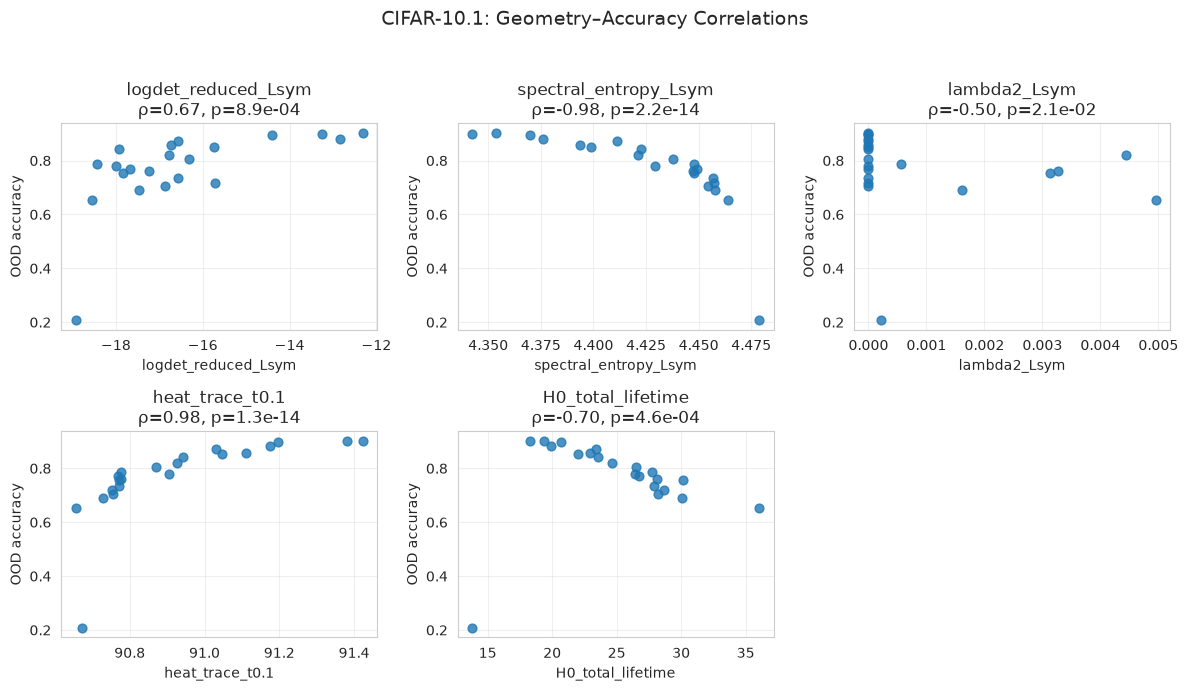

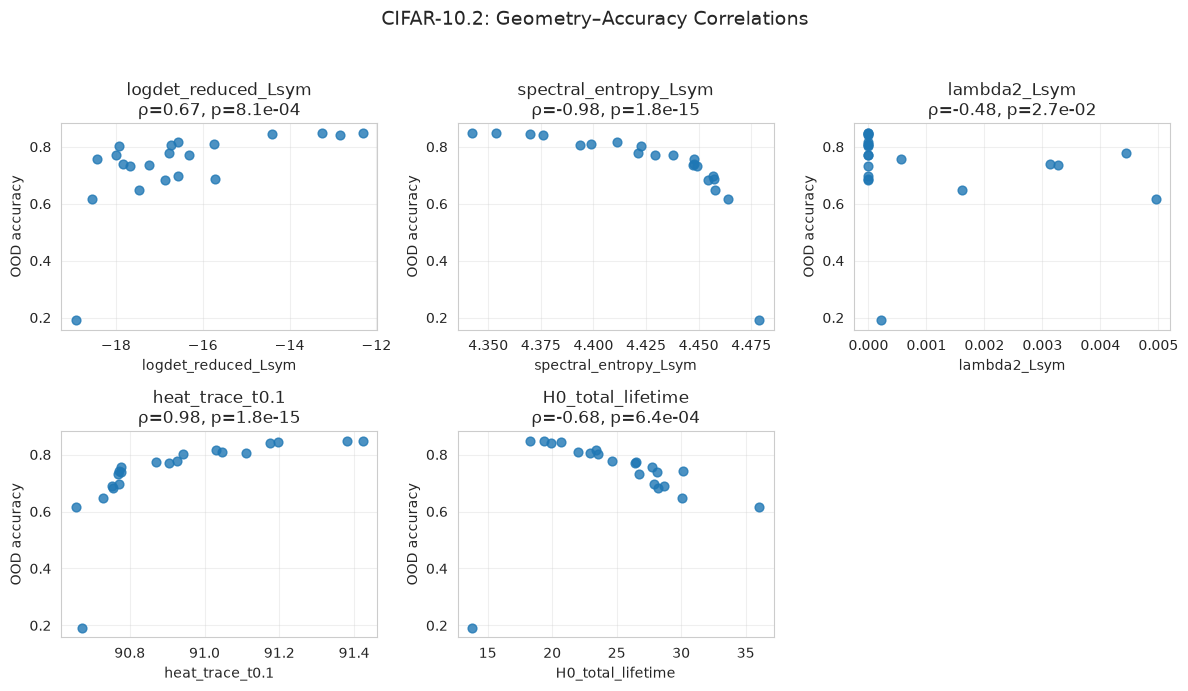

In [31]:
# CELL 30
# Plot checkpoint-wise geometry–accuracy correlations.

def plot_correlation_panel(
    df,
    metrics,
    acc_col="acc",
    title_prefix="CIFAR-10.1",
    ncols=3,
):
    import math
    import matplotlib.pyplot as plt

    n = len(metrics)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, metrics):
        if metric not in df.columns:
            ax.set_title(f"{metric}\nmissing")
            ax.axis("off")
            continue

        x = df[metric].to_numpy(dtype=float)
        y = df[acc_col].to_numpy(dtype=float)

        finite = np.isfinite(x) & np.isfinite(y)
        rho, p = safe_spearman(x[finite], y[finite])

        ax.scatter(x[finite], y[finite], s=40, alpha=0.8)

        if np.isfinite(rho):
            ax.set_title(f"{metric}\nρ={rho:.2f}, p={p:.1e}")
        else:
            ax.set_title(f"{metric}\nρ undefined")

        ax.set_xlabel(metric)
        ax.set_ylabel("OOD accuracy")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(metrics):]:
        ax.axis("off")

    fig.suptitle(
        f"{title_prefix}: Geometry–Accuracy Correlations",
        fontsize=14
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


metrics_to_plot = [
    "logdet_reduced_Lsym",
    "spectral_entropy_Lsym",
    "lambda2_Lsym",
    "heat_trace_t0.1",
    "H0_total_lifetime",
]


plot_correlation_panel(
    df_corr,
    metrics=metrics_to_plot,
    acc_col="acc",
    title_prefix="CIFAR-10.1",
)

plot_correlation_panel(
    df_corr2,
    metrics=metrics_to_plot,
    acc_col="acc",
    title_prefix="CIFAR-10.2",
)

In [32]:
# CELL 31
# Flow: source-ID class geometry across checkpoints → OOD accuracy of same class across checkpoints → Spearman correlation


# Per-class source-geometry vs OOD per-class accuracy analysis.

@torch.inference_mode()
def per_class_acc_over_checkpoints(
    ckpt_dir,
    eval_loader,
    num_classes=10,
    arch="erm"
):
    """
    OOD per-class accuracy for every checkpoint.
    """
    cks = sorted(
        os.path.join(ckpt_dir, f)
        for f in os.listdir(ckpt_dir)
        if f.endswith(".pt") and "best" not in f
    )

    rows = []

    for p in cks:
        model = load_model(p, arch=arch)

        _, per_class, _, _, _, _ = evaluate_clean_ultrafast(
            model,
            eval_loader,
            want_ci=False,
            want_calibration=False,
            use_amp=True
        )

        row = {"ckpt": os.path.basename(p)}

        for c in range(num_classes):
            row[f"acc_c{c}"] = float(per_class.get(c, np.nan))

        rows.append(row)

    return pd.DataFrame(rows)


def single_class_graph_metric(
    X,
    metric_name="logdet_reduced_Lsym",
    k=10,
    per_class=100,
    seed=0
):
    """
    Compute one requested graph metric for one class only.

    This avoids running H0/Ricci/etc. when they are not needed.
    """
    X = np.asarray(X, dtype=np.float64)

    if len(X) < 3:
        return np.nan

    rng = np.random.RandomState(seed)

    if len(X) > per_class:
        idx = rng.choice(len(X), size=per_class, replace=False)
        X = X[idx]

    X = l2_normalize(X)

    W = build_weighted_mutual_knn(
        X,
        k=min(k, len(X) - 1)
    )

    Lsym = normalized_laplacian(W)

    if metric_name == "logdet_reduced_Lsym":
        return reduced_logdet_Lsym(Lsym)

    if metric_name == "spectral_entropy_Lsym":
        return spectral_entropy(Lsym)

    if metric_name == "lambda2_Lsym":
        return algebraic_connectivity(Lsym)

    if metric_name.startswith("heat_trace_t"):
        t = float(metric_name.replace("heat_trace_t", ""))
        return heat_kernel_traces(Lsym, t_list=(t,))[t]

    if metric_name == "ricci_mean":
        return ricci_edge_mean_from_graph(
            X,
            W,
            alpha=0.5,
            sinkhorn_reg=1e-2
        )

    raise ValueError(f"Unsupported per-class graph metric: {metric_name}")


def per_class_metric_over_checkpoints(
    ckpt_dir,
    id_dataset,
    cls,
    layer="preclassifier",
    k=10,
    per_class=100,
    metric_name="logdet_reduced_Lsym",
    arch="erm"
):
    """
    Compute one source-ID geometry metric for one class
    across all checkpoints.
    """
    idxs = [
        i for i in range(len(id_dataset))
        if int(id_dataset[i][1]) == int(cls)
    ]

    if len(idxs) < 5:
        raise ValueError(
            f"ID dataset has too few samples for class {cls}: {len(idxs)}"
        )

    loader_id_cls = DataLoader(
        Subset(id_dataset, idxs),
        batch_size=256,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    cks = sorted(
        os.path.join(ckpt_dir, f)
        for f in os.listdir(ckpt_dir)
        if f.endswith(".pt") and "best" not in f
    )

    rows = []

    for p in cks:
        X, _ = extract_embeddings(
            p,
            loader_id_cls,
            layer=layer,
            arch=arch
        )

        value = single_class_graph_metric(
            X,
            metric_name=metric_name,
            k=k,
            per_class=per_class,
            seed=0
        )

        rows.append({
            "ckpt": os.path.basename(p),
            metric_name: value
        })

    return pd.DataFrame(rows)


def source_only_per_class_panel(
    ckpt_dir,
    id_dataset,
    ood_loader,
    layer="preclassifier",
    k=10,
    per_class=100,
    metric_name="logdet_reduced_Lsym",
    classes=range(10),
    make_individual_plots=True,
    arch="erm"
):
    """
    For each class c:

        source-ID geometry for class c
        vs.
        OOD accuracy for class c

    correlated across checkpoints.
    """
    classes = list(classes)

    acc_df = per_class_acc_over_checkpoints(
        ckpt_dir,
        ood_loader,
        num_classes=10,
        arch=arch
    )

    rows = []

    for cls in classes:
        metr_df = per_class_metric_over_checkpoints(
            ckpt_dir,
            id_dataset,
            cls,
            layer=layer,
            k=k,
            per_class=per_class,
            metric_name=metric_name,
            arch=arch
        )

        df = pd.merge(metr_df, acc_df, on="ckpt", how="inner")

        x = df[metric_name].to_numpy(dtype=float)
        y = df[f"acc_c{cls}"].to_numpy(dtype=float)

        finite = np.isfinite(x) & np.isfinite(y)

        rho, p = safe_spearman(
            x[finite],
            y[finite]
        )

        rows.append({
            "class": int(cls),
            "metric": metric_name,
            "rho": rho,
            "p": p,
            "n_ckpt": int(finite.sum())
        })

        if make_individual_plots:
            plt.figure(figsize=(3.4, 2.7))
            plt.scatter(x[finite], y[finite], s=14, alpha=0.75)

            plt.title(
                f"Class {cls}: ρ={rho:.2f}, p={p:.1e}"
                if np.isfinite(rho)
                else f"Class {cls}: correlation undefined"
            )

            plt.xlabel(metric_name)
            plt.ylabel(f"CIFAR-10.1 accuracy — class {cls}")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    result = pd.DataFrame(rows)

    # Ten per-class tests are exploratory; give a simple
    # multiple-testing-corrected p-value as well.
    result["p_bonferroni"] = np.minimum(
        result["p"] * len(classes),
        1.0
    )

    return result

In [33]:
# CELL 32

# Run source-only per-class analysis:
# source CIFAR-10 validation geometry vs CIFAR-10.1 per-class accuracy.

# df_pc_sourceonly_logdet = source_only_per_class_panel(
#     ckdir,
#     id_dataset=val_src_subset,
#     ood_loader=loader_101, # loader_102
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     metric_name="logdet_reduced_Lsym", # "ricci_mean"
#     classes=range(10),
#     make_individual_plots=True,
#     arch="erm",
# )

# df_pc_sourceonly_logdet.to_csv(
#     "per_class_corr_c101_logdet_sourceonly.csv", # "per_class_corr_c101_ricci_sourceonly.csv"
#     index=False
# )

# df_pc_sourceonly_logdet


# df_pc_sourceonly_ricci = source_only_per_class_panel(
#     ckdir,
#     id_dataset=val_src_subset,
#     ood_loader=loader_101, # loader_102
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     metric_name="ricci_mean", 
#     classes=range(10),
#     make_individual_plots=True,
#     arch="erm",
# )

# df_pc_sourceonly_ricci.to_csv(
#     "per_class_corr_c101_ricci_sourceonly.csv",  
#     index=False
# )

# df_pc_sourceonly_ricci



df_pc_sourceonly_logdet = pd.read_csv("per_class_corr_c101_logdet_sourceonly.csv")
df_pc_sourceonly_ricci = pd.read_csv("per_class_corr_c101_ricci_sourceonly.csv")

#### Creates a single 2×5 figure showing the per-class source-geometry vs CIFAR-10.1 accuracy correlations computed in Cells 31–32.

In [34]:
# CELL 33
# Flow: class-wise source metric → same-class OOD accuracy → Spearman correlation → 10-panel figure


# Source-only per-class composite plot (2x5 grid)

def source_only_per_class_composite(
    ckpt_dir,
    id_dataset,
    ood_loader,
    layer="preclassifier",
    k=10,
    per_class=100,
    metric_name="logdet_reduced_Lsym",
    classes=range(10),
    save_path="fig_perclass_sourceonly.png",
    arch="erm",
):
    classes = list(classes)

    acc_df = per_class_acc_over_checkpoints(
        ckpt_dir, ood_loader, num_classes=10, arch=arch
    )

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    rows = []

    for idx, cls in enumerate(classes):
        metr_df = per_class_metric_over_checkpoints(
            ckpt_dir,
            id_dataset,
            cls,
            layer=layer,
            k=k,
            per_class=per_class,
            metric_name=metric_name,
            arch=arch,
        )

        df = pd.merge(metr_df, acc_df, on="ckpt", how="inner")
        ycol = f"acc_c{cls}"

        if metric_name not in df.columns or ycol not in df.columns:
            print(f"[Class {cls}] Missing columns for plotting.")
            axes[idx].axis("off")
            continue

        x = df[metric_name].to_numpy(dtype=float)
        y = df[ycol].to_numpy(dtype=float)
        finite = np.isfinite(x) & np.isfinite(y)

        rho, p = safe_spearman(x[finite], y[finite])

        rows.append({
            "class": int(cls),
            "metric": metric_name,
            "rho": rho,
            "p": p,
            "n_ckpt": int(finite.sum()),
        })

        ax = axes[idx]
        ax.scatter(x[finite], y[finite], s=18, alpha=0.75)

        if np.isfinite(rho):
            ax.set_title(f"C{cls}: ρ={rho:.2f}, p={p:.1g}", fontsize=10)
        else:
            ax.set_title(f"C{cls}: correlation undefined", fontsize=10)

        ax.set_xlabel(metric_name, fontsize=9)
        ax.set_ylabel(f"OOD acc (c={cls})", fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)

    for ax in axes[len(classes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved source-only per-class figure to: {save_path}")

    return pd.DataFrame(rows)

In [35]:
# CELL 34

# Run source-only per-class Ollivier-Ricci composite analysis.

# df_pc_grid_ricci = source_only_per_class_composite(
#     ckdir,
#     id_dataset=val_src_subset,      # source-ID geometry only
#     ood_loader=loader_101,          #loader_102 # OOD labels used only for retrospective accuracy
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     metric_name="ricci_mean",      # "logdet_reduced_Lsym"
#     classes=range(10),
#     save_path="fig_perclass_ricci_sourceonly.png",  # fig_perclass_logdet_sourceonly.png
#     arch="erm",
# )

# df_pc_grid_ricci.to_csv("per_class_corr_ricci_sourceonly.csv", index=False) # per_class_corr_logdet_sourceonly.csv
# df_pc_grid_ricci




# df_pc_grid_logdet = source_only_per_class_composite(
#     ckdir,
#     id_dataset=val_src_subset,      # source-ID geometry only
#     ood_loader=loader_101,          #loader_102 # OOD labels used only for retrospective accuracy
#     layer="preclassifier",
#     k=10,
#     per_class=100,
#     metric_name="logdet_reduced_Lsym",      
#     classes=range(10),
#     save_path="fig_perclass_logdet_sourceonly.png",   
#     arch="erm",
# )

# df_pc_grid_logdet.to_csv("per_class_corr_logdet_sourceonly.csv", index=False) # 
# df_pc_grid_logdet



df_pc_grid_logdet = pd.read_csv("per_class_corr_logdet_sourceonly.csv")
df_pc_grid_ricci = pd.read_csv("per_class_corr_ricci_sourceonly.csv")

Post-hoc strongest heat scale: heat_trace_t0.3
          heat_col       rho             p
1  heat_trace_t0.3  0.985714  3.666708e-16
2  heat_trace_t1.0  0.983117  1.774768e-15
3  heat_trace_t3.0  0.981818  3.570352e-15
0  heat_trace_t0.1  0.979221  1.256785e-14
Explained variance PC1: 0.9983531652679147


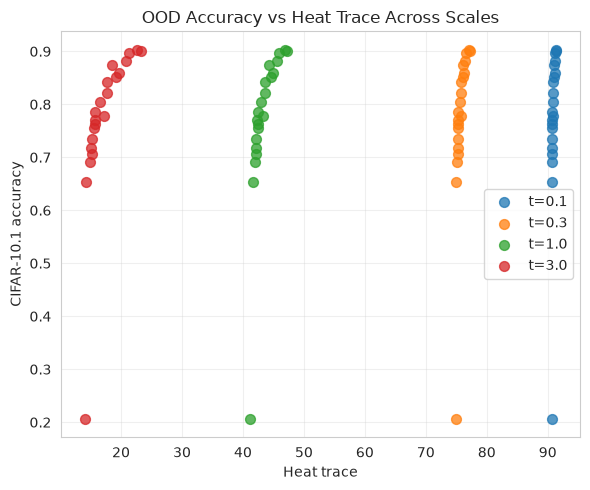

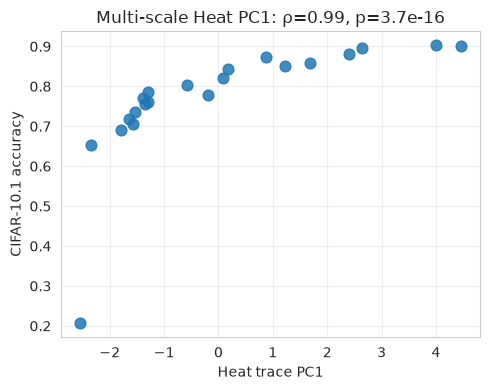

In [36]:
# CELL 35

# Flow: 4 heat scales → correlate each with CIFAR-10.1 accuracy → identify strongest scale
#and
# 4 heat scales → standardize → PCA → PC1 → compare PC1 with OOD accuracy



# Post-hoc multi-scale heat-kernel analysis on CIFAR-10.1.
# OOD accuracy is used only for retrospective correlation analysis.

heat_cols = [
    "heat_trace_t0.1",
    "heat_trace_t0.3",
    "heat_trace_t1.0",
    "heat_trace_t3.0",
]

best_col_posthoc, heat_corrs = select_best_heat_scale_posthoc(
    df_corr,
    acc_col="acc",
    heat_cols=heat_cols,
)

print("Post-hoc strongest heat scale:", best_col_posthoc)
print(heat_corrs)


# Source-derived multi-scale summary: PCA uses only the heat metrics,
# not OOD accuracy.
df_corr["heat_pc1"], pca = heat_trace_pc1(
    df_corr,
    heat_cols,
)

print(
    "Explained variance PC1:",
    pca.explained_variance_ratio_[0]
)


plt.figure(figsize=(6, 5))

for col in heat_cols:
    finite = (
        np.isfinite(df_corr[col].to_numpy(dtype=float))
        & np.isfinite(df_corr["acc"].to_numpy(dtype=float))
    )

    plt.scatter(
        df_corr.loc[finite, col],
        df_corr.loc[finite, "acc"],
        label=col.replace("heat_trace_t", "t="),
        alpha=0.75,
        s=50,
    )

plt.xlabel("Heat trace")
plt.ylabel("CIFAR-10.1 accuracy")
plt.title("OOD Accuracy vs Heat Trace Across Scales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


finite = (
    np.isfinite(df_corr["heat_pc1"].to_numpy(dtype=float))
    & np.isfinite(df_corr["acc"].to_numpy(dtype=float))
)

rho_pc1, p_pc1 = safe_spearman(
    df_corr.loc[finite, "heat_pc1"],
    df_corr.loc[finite, "acc"],
)

plt.figure(figsize=(5, 4))

plt.scatter(
    df_corr.loc[finite, "heat_pc1"],
    df_corr.loc[finite, "acc"],
    s=60,
    alpha=0.85,
)

plt.xlabel("Heat trace PC1")
plt.ylabel("CIFAR-10.1 accuracy")
plt.title(f"Multi-scale Heat PC1: ρ={rho_pc1:.2f}, p={p_pc1:.1e}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Defines simple non-topological baselines to compare against TopoGeoScore

In [37]:
# CELL 36

# Flow: embeddings / graph / model → simple baseline statistics (embedding anisotropy, basic graph statistics, parameter norm, and logit norm.)


# Baseline diagnostics suite

def embedding_anisotropy(X, seed=0):
    """
    Representation baselines:
      - effective_rank: entropy-based effective rank of singular values
      - top1_ratio: largest singular value / total singular-value mass
      - mean_cos: mean pairwise cosine similarity
    """
    X = np.asarray(X, dtype=np.float64)
    X = l2_normalize(X)

    rng = np.random.RandomState(seed)
    n = min(len(X), 2000)
    idx = rng.choice(len(X), size=n, replace=False)
    Xs = X[idx]

    # Spectral anisotropy is computed on centered embeddings.
    X_centered = Xs - Xs.mean(axis=0, keepdims=True)

    s = np.linalg.svd(X_centered, full_matrices=False, compute_uv=False)
    s = np.clip(s, 1e-12, None)

    p = s / s.sum()
    eff_rank = float(np.exp(-(p * np.log(p)).sum()))
    top1_ratio = float(s[0] / s.sum())

    # Cosine similarity must use the normalized, uncentered embeddings.
    m = min(n, 800)
    Z = Xs[:m]
    C = Z @ Z.T

    mean_cos = (
        float((C.sum() - np.trace(C)) / (m * (m - 1)))
        if m > 1 else np.nan
    )

    return {
        "eff_rank": eff_rank,
        "top1_ratio": top1_ratio,
        "mean_cos": mean_cos,
    }


def graph_simple_metrics(W):
    """Basic unweighted statistics of the mutual-kNN graph."""
    B = W.copy().tocsr()
    B.data[:] = 1.0
    B.eliminate_zeros()

    deg = np.asarray(B.sum(axis=1)).ravel()
    n = B.shape[0]

    avg_deg = float(deg.mean()) if n else np.nan
    density = float(B.nnz / (n * (n - 1))) if n > 1 else np.nan

    G = nx.from_scipy_sparse_array(B, create_using=nx.Graph)
    clustering = float(nx.average_clustering(G)) if n else np.nan

    return {
        "avg_degree": avg_deg,
        "density": density,
        "clustering": clustering,
    }


@torch.inference_mode()
def weight_and_logit_norms(model, loader, num_batches=5):
    """Model-scale baselines: global parameter L2 norm and mean logit L2 norm."""
    sq_norm = sum(
        float(p.detach().float().pow(2).sum().cpu())
        for p in model.parameters()
    )
    weight_norm = float(np.sqrt(sq_norm))

    model.eval()
    logit_norms = []

    for batch_idx, (x, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break

        x = x.to(device, non_blocking=True)
        logits = model(x)

        logit_norms.extend(
            logits.float().norm(dim=1).cpu().numpy().tolist()
        )

    logit_norm = float(np.mean(logit_norms)) if logit_norms else np.nan

    return {
        "weight_norm": weight_norm,
        "logit_norm": logit_norm,
    }

#### Builds a baseline comparison table across checkpoints: TopoGeoScore geometry, PH, simple embedding/graph statistics, weight/logit norms, and a gradient/Jacobian baseline, then correlates each with OOD accuracy.

In [38]:
# CELL 37

# Flow: checkpoint → source embeddings/baselines → OOD accuracy → Spearman comparison


# Baseline diagnostics + PH competitor across checkpoints

def list_checkpoints(ckpt_dir, include_best=False):
    files = [
        os.path.join(ckpt_dir, f)
        for f in os.listdir(ckpt_dir)
        if f.endswith(".pt") and f.startswith("ep")
    ]
    files = sorted(files)

    if include_best:
        best_path = os.path.join(ckpt_dir, "best.pt")
        if os.path.exists(best_path):
            files.append(best_path)

    return files


def jacobian_fro_norm_hutchinson(model, loader, num_batches=3, num_probes=4, seed=0):
    """
    Hutchinson estimate of the input-output Jacobian Frobenius norm:
        ||J||_F^2 = E_v ||J^T v||^2
    with Rademacher probes v.
    """
    model.eval()
    rng = np.random.RandomState(seed)
    batch_values = []

    for batch_idx, (x, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break

        x = x.to(device, non_blocking=True).detach()
        x.requires_grad_(True)
        logits = model(x)

        fro_sq = torch.zeros(x.shape[0], device=x.device)

        for probe_idx in range(num_probes):
            v_np = rng.choice([-1.0, 1.0], size=tuple(logits.shape))
            v = torch.tensor(v_np, device=logits.device, dtype=logits.dtype)

            scalar = (logits * v).sum()
            grad = torch.autograd.grad(
                scalar,
                x,
                retain_graph=(probe_idx < num_probes - 1),
                create_graph=False
            )[0]

            fro_sq += grad.flatten(1).pow(2).sum(dim=1)

        fro = torch.sqrt(fro_sq / num_probes)
        batch_values.extend(fro.detach().cpu().numpy().tolist())

    return float(np.mean(batch_values)) if batch_values else np.nan


def compute_metric_pack_for_ckpt_v2(
    ckpt_path,
    loader_for_embeddings,
    loader_for_jacobian=None,
    layer="preclassifier",
    k=10,
    per_class=100,
    include_ph=True,
    arch="erm",
):
    model = load_model(ckpt_path, arch=arch)
    model.eval()

    X, y = extract_embeddings(
        ckpt_path,
        loader_for_embeddings,
        layer=layer,
        l2_norm=True,
        arch=arch
    )

    out = {}

    # Main class-conditional geometry metrics.
    topo = topology_metrics_from_embeddings(
        X,
        y,
        k=k,
        per_class=per_class
    )

    for name, value in topo.items():
        if np.isscalar(value):
            out[f"topo_{name}"] = float(value)

    # Explicit Ricci alias for baseline tables.
    out["mean_ricci"] = float(
        topo.get("ricci_mean", np.nan)
    )

    # Representation anisotropy baselines.
    anis = embedding_anisotropy(X)
    out.update({
        f"anis_{name}": float(value)
        for name, value in anis.items()
    })

    # Generic GLOBAL graph statistics.
    # These are baselines, not TopoGeoScore class-conditional metrics.
    Xb, _ = class_balanced_sample(X, y, per_class=per_class)
    W_global = build_weighted_mutual_knn(Xb, k=k)

    graph_stats = graph_simple_metrics(W_global)
    out.update({
        f"graph_global_{name}": float(value)
        for name, value in graph_stats.items()
    })

    # Model-scale baselines.
    model_stats = weight_and_logit_norms(
        model,
        loader_for_embeddings
    )
    out.update({
        name: float(value)
        for name, value in model_stats.items()
    })

    # Gradient/Jacobian baseline.
    if loader_for_jacobian is not None:
        out["jacobian_fro"] = jacobian_fro_norm_hutchinson(
            model,
            loader_for_jacobian,
            num_batches=3,
            num_probes=4,
            seed=0
        )
    else:
        out["jacobian_fro"] = np.nan

    # PH baselines must remain class-conditional.
    if include_ph:
        out["PH_H0_total_lifetime"] = float(
            topo.get("H0_total_lifetime", np.nan)
        )

        h1 = h1_stats_pca(
            X, y,
            per_class=per_class,
            pca_dim=10,
            n_landmarks=64,
            n_boot=8,
            rng=0
        )

        out["PH_H1_total_mean"] = float(h1["H1_total_mean"])
        out["PH_H1_total_std"] = float(h1["H1_total_std"])

    return out



def eval_acc_on(loader, ckpt_path, arch="erm"):
    """Evaluate checkpoint accuracy on a loader."""
    model = load_model(ckpt_path, arch=arch)

    acc, *_ = evaluate_clean_ultrafast(
        model,
        loader,
        want_ci=False,
        want_calibration=False,
        use_amp=True,
    )

    return float(acc)



def correlation_baseline_table_v2(
    ckpt_dir,
    ood_loader,
    emb_loader_for_metrics,
    src_loader_for_jac=None,
    layer="preclassifier",
    k=10,
    per_class=100,
    max_ckpts=None,
    arch="erm",
):
    ckpts = list_checkpoints(
        ckpt_dir,
        include_best=False
    )

    if max_ckpts is not None:
        ckpts = ckpts[:max_ckpts]

    records = []

    for ck in tqdm(ckpts, desc="Baseline + PH table"):
        acc = eval_acc_on(ood_loader, ck, arch=arch)

        pack = compute_metric_pack_for_ckpt_v2(
            ck,
            emb_loader_for_metrics,
            loader_for_jacobian=src_loader_for_jac,
            layer=layer,
            k=k,
            per_class=per_class,
            include_ph=True,
            arch=arch,
        )

        pack["ckpt"] = os.path.basename(ck)
        pack["acc_ood"] = float(acc)
        records.append(pack)

    df = pd.DataFrame(records)

    rows = []

    for col in df.columns:
        if col in ("ckpt", "acc_ood"):
            continue

        x = df[col].to_numpy(dtype=float)
        y = df["acc_ood"].to_numpy(dtype=float)

        finite = np.isfinite(x) & np.isfinite(y)
        rho, p = safe_spearman(x[finite], y[finite])

        rows.append({
            "metric": col,
            "spearman_rho": rho,
            "abs_rho": abs(rho) if np.isfinite(rho) else np.nan,
            "p_value": p,
            "n_ckpt": int(finite.sum()),
        })

    corr_table = pd.DataFrame(rows)
    corr_table = corr_table.sort_values(
        "abs_rho",
        ascending=False
    ).reset_index(drop=True)

    return df, corr_table

#### Runs the full baseline + PH + geometry correlation table across checkpoints on CIFAR-10.1, then saves both raw checkpoint metrics and the correlation summary.

In [ ]:
# CELL 38
# Flow: checkpoints → source-only metrics/baselines → CIFAR-10.1 accuracy → Spearman table → CSVs



# Run source-only baseline + PH correlation table on CIFAR-10.1.

val_src_loader = DataLoader(
    val_src_subset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

loader_101 = DataLoader(
    c10_1,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

df_ckpt_metrics_v2, df_corr_table_v2 = correlation_baseline_table_v2(
    ckdir,
    ood_loader=loader_101,
    emb_loader_for_metrics=loader_id_metrics,
    src_loader_for_jac=val_src_loader,
    layer="preclassifier",
    k=10,
    per_class=100,
    max_ckpts=None,
    arch="erm",
)

print("\nTop correlations with CIFAR-10.1 accuracy:")
display(df_corr_table_v2.head(25))

corr_path = "baseline_vs_geometry_with_PH_corr_table_source_only.csv"
metrics_path = "checkpoint_metrics_with_PH_source_only.csv"

df_corr_table_v2.to_csv(corr_path, index=False)
df_ckpt_metrics_v2.to_csv(metrics_path, index=False)

print(f"Saved: {corr_path}")
print(f"Saved: {metrics_path}")

In [ ]:
# CELL 39
# Flow: correlation table → ranked/family plots and checkpoint metrics → torsion vs PH scatter


# Visual comparison of geometry, PH, and conventional baselines.

def plot_ranked_correlations(df_corr, top_k=15):
    df = df_corr.sort_values("abs_rho", ascending=False).head(top_k)

    plt.figure(figsize=(8, 0.45 * len(df)))
    plt.barh(df["metric"], df["spearman_rho"])

    plt.axvline(0, linewidth=0.8)
    plt.xlabel("Spearman ρ with OOD accuracy")
    plt.title("Strongest checkpoint diagnostics by |ρ|")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_ranked_correlations(df_corr_table_v2, top_k=30)


def plot_group_summary(df_corr):
    metric = df_corr["metric"].astype(str)

    spectral_mask = metric.str.contains(
        "logdet|heat|entropy|lambda2", regex=True
    )
    ricci_mask = metric.str.contains(
        "ricci", case=False, regex=True
    )
    ph_mask = metric.str.contains(
        "PH_|H0|H1", regex=True
    )

    groups = {
        "Spectral / torsion": df_corr[spectral_mask & ~ph_mask],
        "Ricci": df_corr[ricci_mask],
        "Persistent homology": df_corr[ph_mask],
        "Other baselines": df_corr[~(spectral_mask | ricci_mask | ph_mask)],
    }

    names, means, stds = [], [], []

    for name, group in groups.items():
        vals = group["abs_rho"].dropna()
        if len(vals) == 0:
            continue

        names.append(name)
        means.append(float(vals.mean()))
        stds.append(float(vals.std()) if len(vals) > 1 else 0.0)

    plt.figure(figsize=(7, 4))
    plt.bar(names, means, yerr=stds, alpha=0.85)

    plt.ylabel("Mean |Spearman ρ|")
    plt.title("Diagnostic families vs OOD accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_group_summary(df_corr_table_v2)


def plot_torsion_vs_ph(df_ckpt_metrics):
    torsion_col = "topo_logdet_reduced_Lsym"
    ph_col = "PH_H1_total_mean"

    required = [torsion_col, ph_col, "acc_ood"]
    missing = [col for col in required if col not in df_ckpt_metrics.columns]

    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df = df_ckpt_metrics[required].dropna()

    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        df[torsion_col],
        df[ph_col],
        c=df["acc_ood"],
        cmap="viridis",
        s=60,
        alpha=0.85
    )

    plt.colorbar(sc, label="OOD accuracy")
    plt.xlabel("Normalized-Laplacian log pseudo-determinant")
    plt.ylabel("H1 total lifetime")
    plt.title("Spectral torsion proxy vs H1 persistence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_torsion_vs_ph(df_ckpt_metrics_v2)